In [1]:
METHOD = "DIRICHLET"

# Dirichlet search algorithm

In [2]:
import os
import io
import random
import copy
import torch
import json
import pickle
import contextlib
import numpy as np
from operator import itemgetter
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from mylib import probtools
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from constants import NUM_EPOCHS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[56]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]
    TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

In [6]:
starting_grid_positions = [[24, 25], [29, 36], [19, 27], [23, 26], [8, 20], [16, 30], [9, 15], [27, 41], [7, 30], [9, 1], [2, 28], [32, 14], [4, 38], [21, 35], [15, 12], [7, 34], [35, 35], [9, 5], [33, 20], [41, 38], [2, 25], [19, 5], [18, 3], [20, 39], [8, 12], [18, 37], [3, 37], [17, 39], [31, 36], [3, 25], [4, 32], [14, 30], [34, 37], [34, 36], [3, 1], [5, 19], [30, 14], [19, 17], [17, 7], [28, 24], [11, 10], [10, 34], [33, 14], [30, 13], [18, 21], [24, 35], [3, 39], [36, 21], [42, 39], [12, 27], [19, 31], [11, 28], [11, 15], [8, 14], [4, 33], [18, 16], [23, 24], [12, 9], [16, 33], [23, 41], [36, 22], [17, 36], [17, 31], [40, 40], [20, 23], [21, 12], [24, 12], [30, 9], [20, 16], [5, 35], [19, 21], [6, 32], [12, 10], [9, 36], [3, 11], [3, 28], [37, 6], [43, 39], [30, 19], [4, 36], [28, 37], [11, 34], [29, 34], [34, 19], [4, 43], [6, 36], [10, 38], [33, 37], [1, 19], [21, 23], [6, 39], [7, 26], [20, 40], [31, 9], [28, 30], [18, 26], [3, 35], [31, 30], [40, 38], [35, 34], ]
starting_orientations = [90, 90, 180, 0, 180, 90, 180, 90, 180, 270, 0, 90, 90, 270, 0, 0, 270, 180, 0, 180, 270, 270, 180, 270, 0, 180, 90, 270, 90, 180, 0, 180, 270, 0, 270, 90, 270, 270, 180, 270, 270, 270, 270, 0, 0, 90, 270, 0, 180, 0, 180, 0, 0, 0, 90, 180, 0, 0, 90, 0, 270, 270, 180, 180, 180, 90, 270, 270, 0, 90, 90, 0, 270, 90, 0, 180, 180, 0, 90, 180, 90, 270, 90, 270, 0, 90, 270, 270, 0, 180, 0, 90, 180, 180, 180, 180, 0, 180, 180, 270, ]

In [7]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []


Simulation 1/100


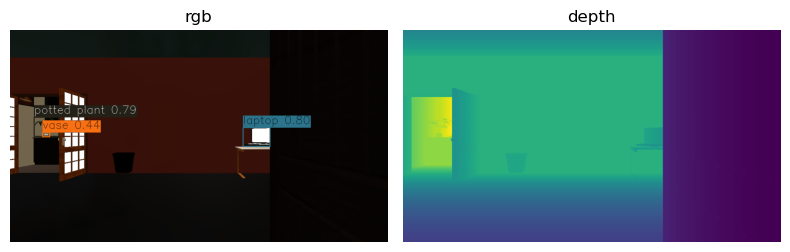

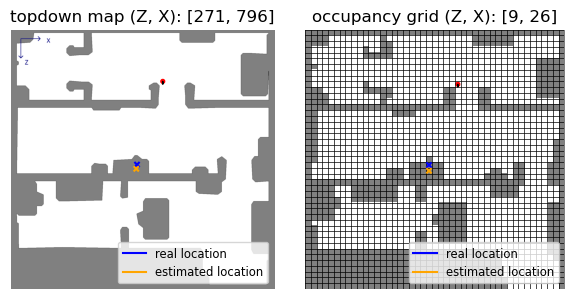


Target object <laptop> found after 197 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 197
Travelled distance: 44.61 m
Computed location error: 0.227 m

Simulation 2/100


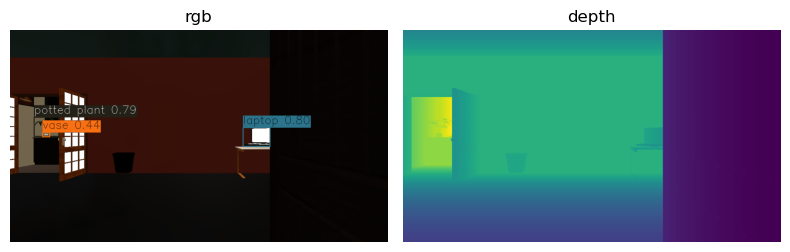

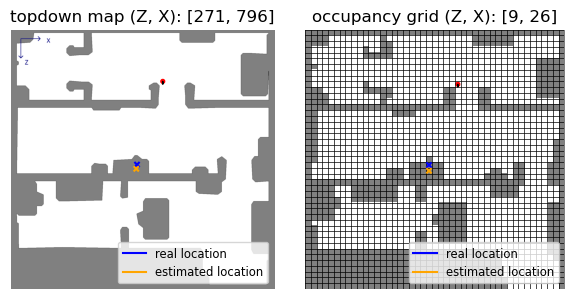


Target object <laptop> found after 145 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 145
Travelled distance: 31.72 m
Computed location error: 0.227 m

Simulation 3/100


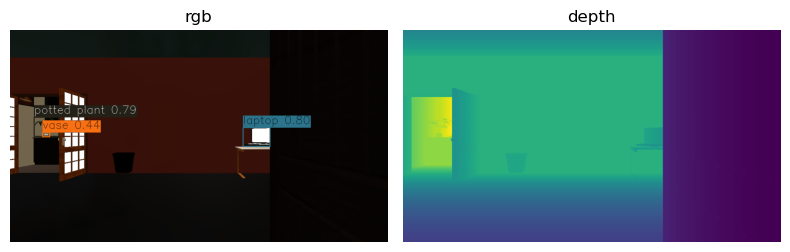

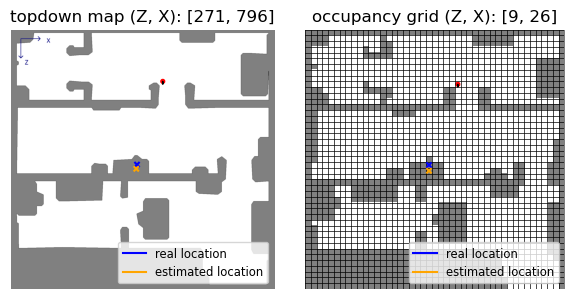


Target object <laptop> found after 189 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 189
Travelled distance: 42.49 m
Computed location error: 0.227 m

Simulation 4/100


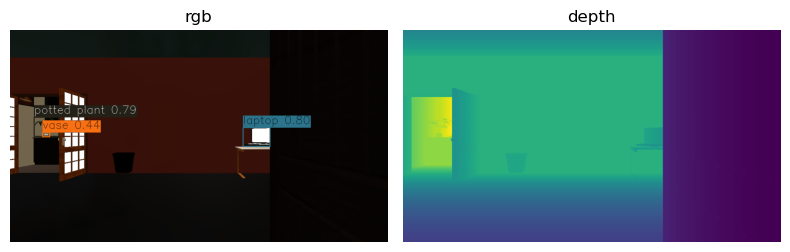

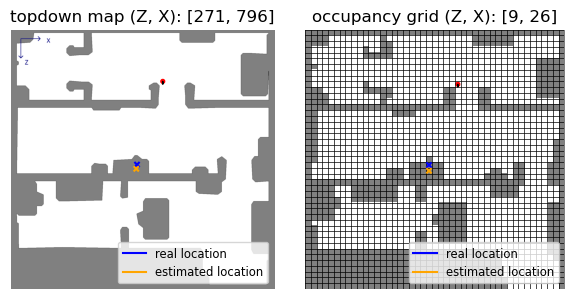


Target object <laptop> found after 194 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 194
Travelled distance: 44.00 m
Computed location error: 0.227 m

Simulation 5/100


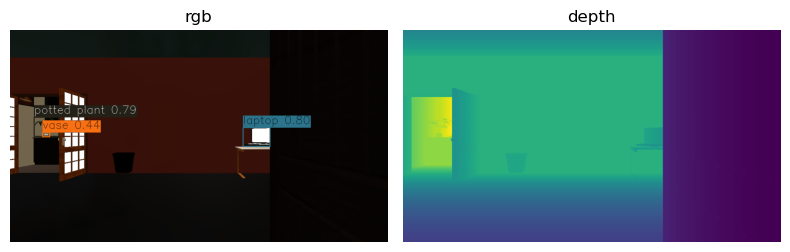

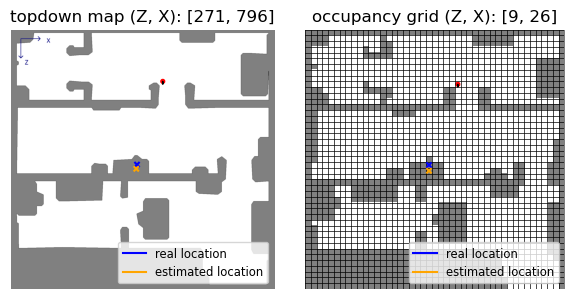


Target object <laptop> found after 55 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 55
Travelled distance: 11.92 m
Computed location error: 0.227 m

Simulation 6/100


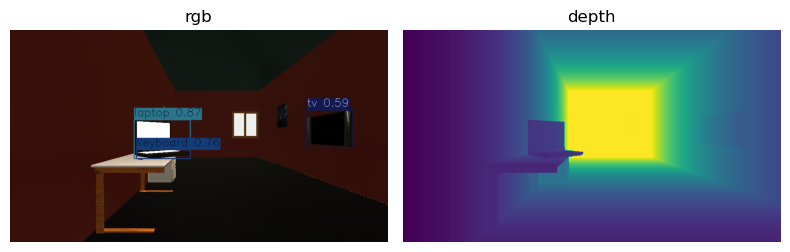

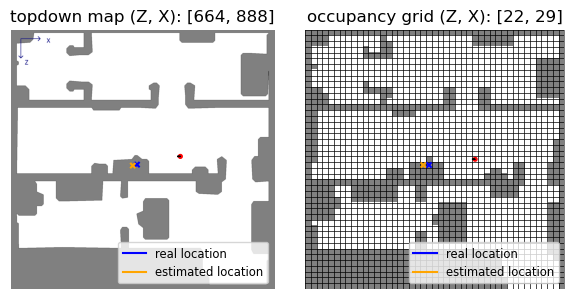


Target object <laptop> found after 171 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 171
Travelled distance: 38.71 m
Computed location error: 0.223 m

Simulation 7/100


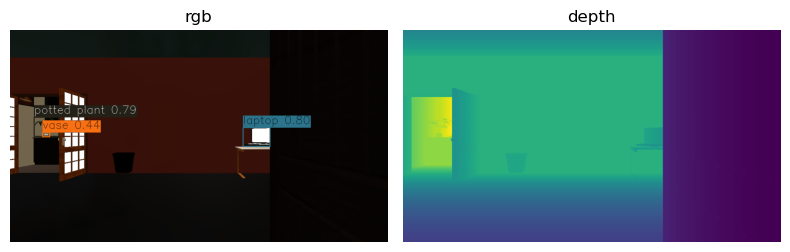

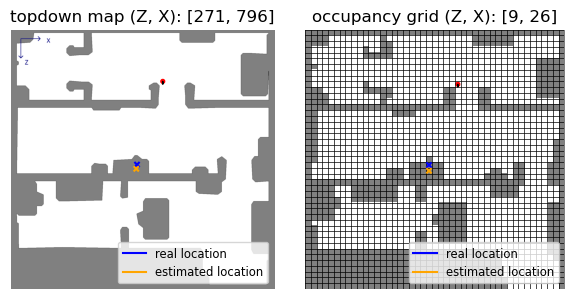


Target object <laptop> found after 65 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 65
Travelled distance: 13.76 m
Computed location error: 0.227 m

Simulation 8/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


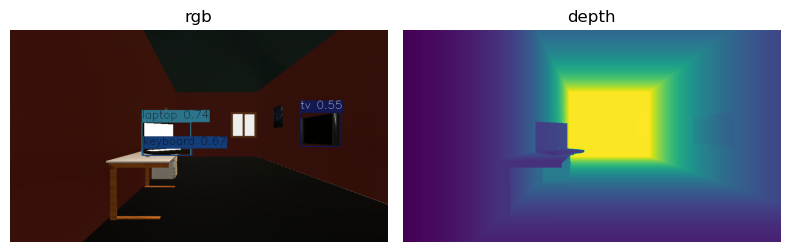

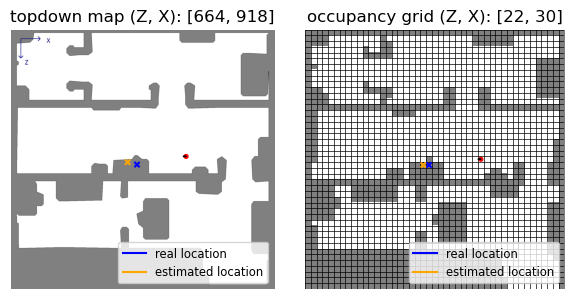


Target object <laptop> not found after 148 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 148
Travelled distance: 33.53 m
Computed location error: 0.507 m

Simulation 9/100


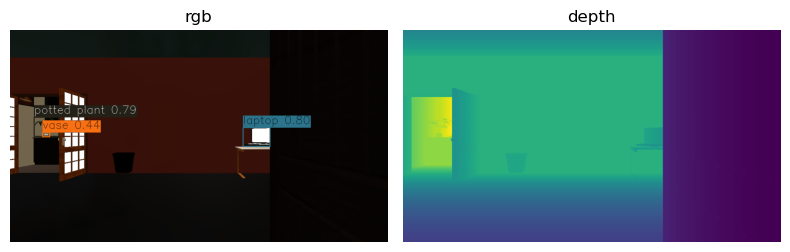

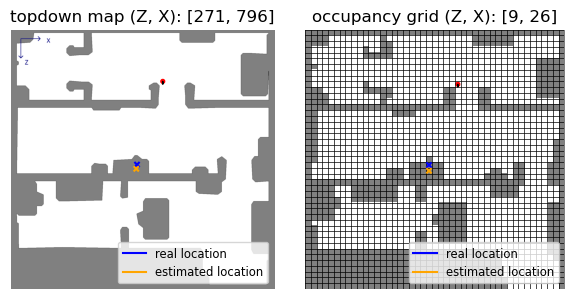


Target object <laptop> found after 44 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 44
Travelled distance: 8.56 m
Computed location error: 0.227 m

Simulation 10/100


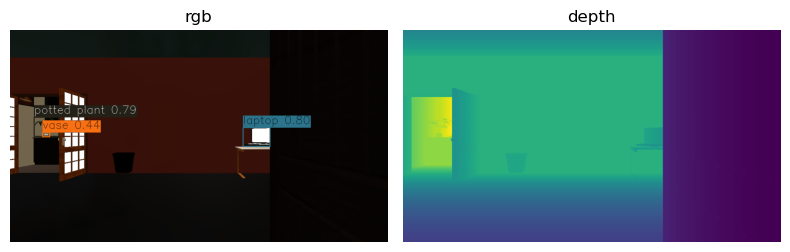

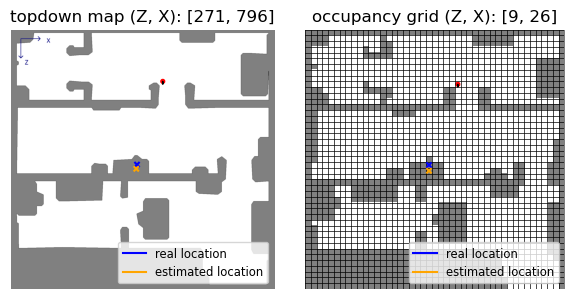


Target object <laptop> found after 46 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 46
Travelled distance: 9.47 m
Computed location error: 0.227 m

Simulation 11/100


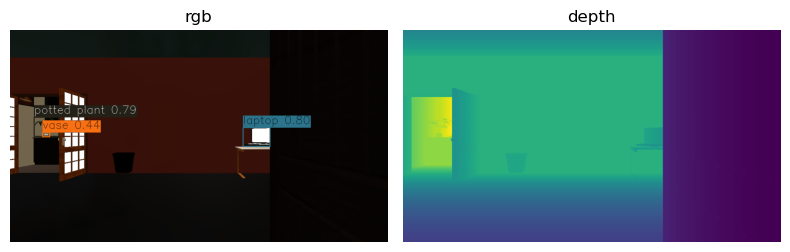

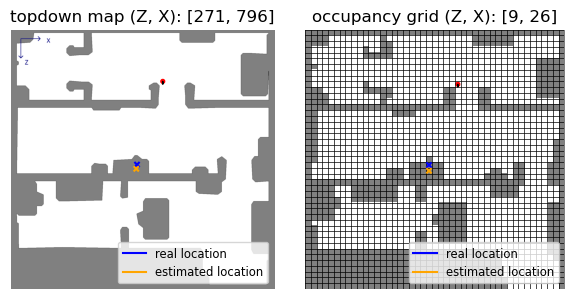


Target object <laptop> found after 77 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 77
Travelled distance: 18.65 m
Computed location error: 0.227 m

Simulation 12/100


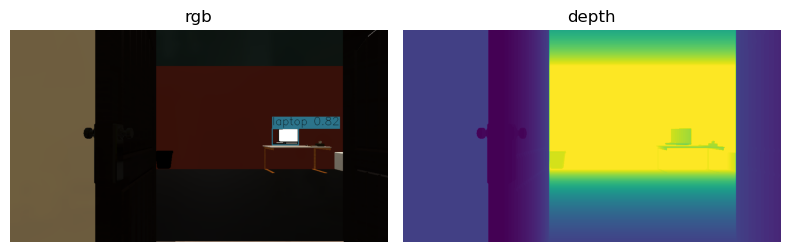

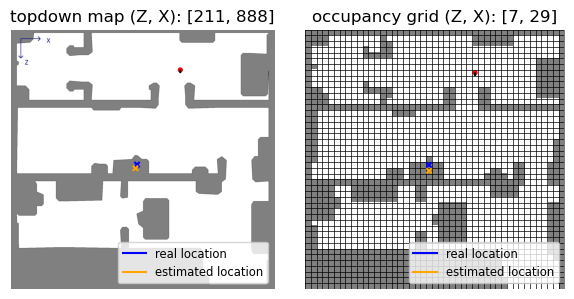


Target object <laptop> found after 261 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 261
Travelled distance: 59.84 m
Computed location error: 0.200 m

Simulation 13/100


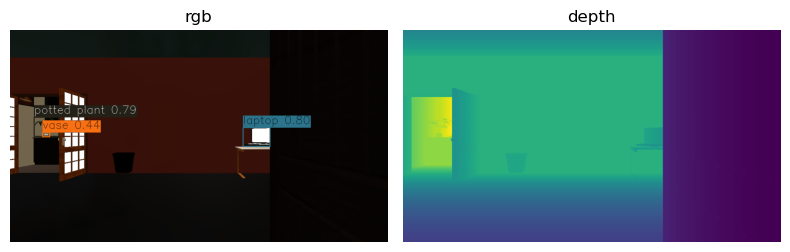

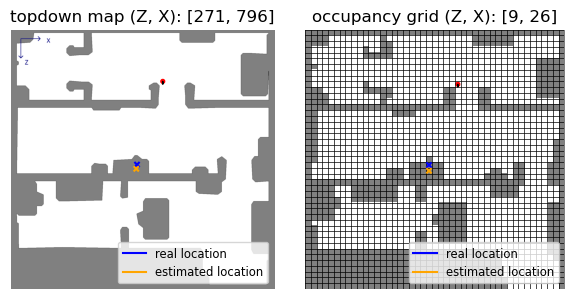


Target object <laptop> found after 38 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 38
Travelled distance: 8.25 m
Computed location error: 0.227 m

Simulation 14/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


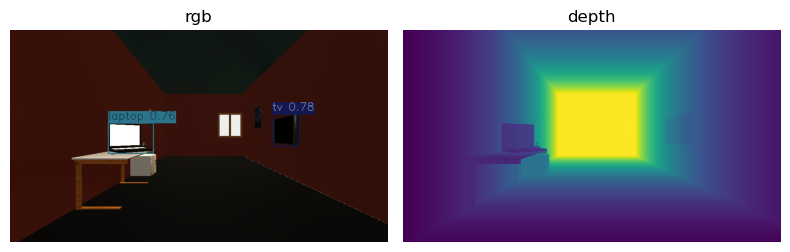

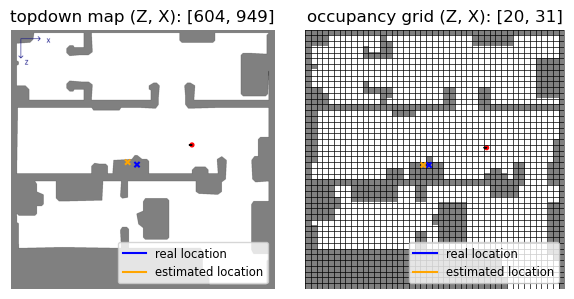


Target object <laptop> not found after 73 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 73
Travelled distance: 13.67 m
Computed location error: 0.507 m

Simulation 15/100


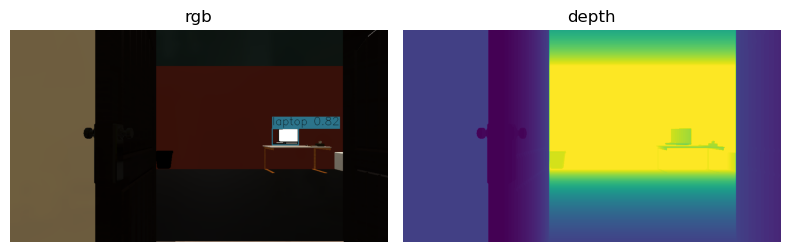

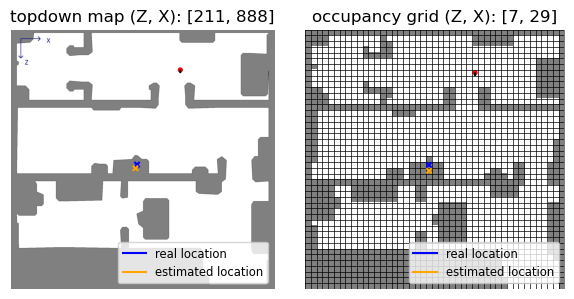


Target object <laptop> found after 147 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 147
Travelled distance: 33.92 m
Computed location error: 0.200 m

Simulation 16/100


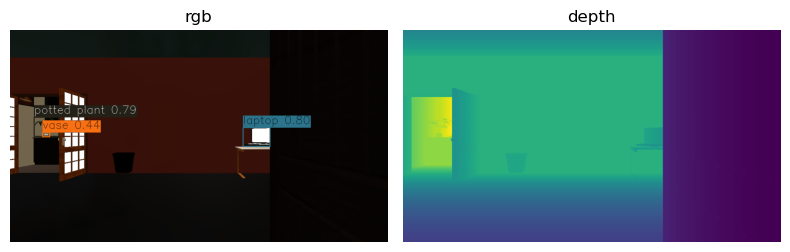

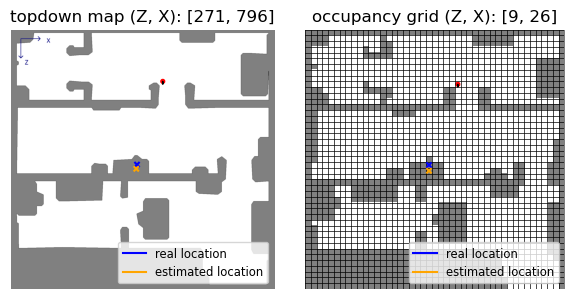


Target object <laptop> found after 38 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 38
Travelled distance: 7.33 m
Computed location error: 0.227 m

Simulation 17/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


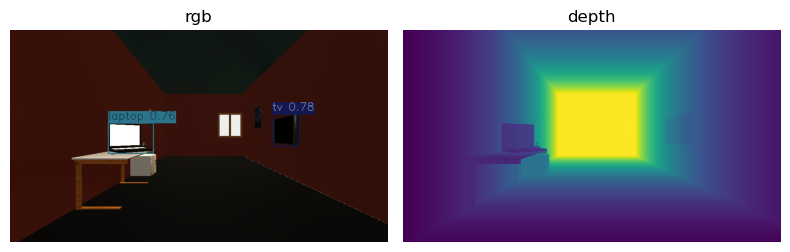

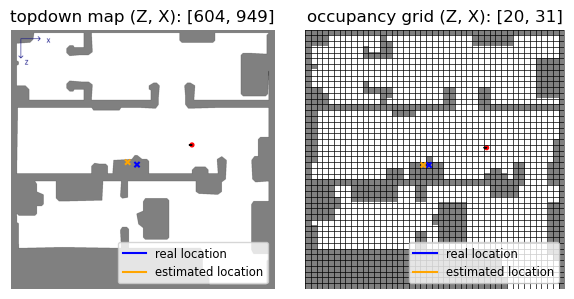


Target object <laptop> not found after 67 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 67
Travelled distance: 13.04 m
Computed location error: 0.507 m

Simulation 18/100


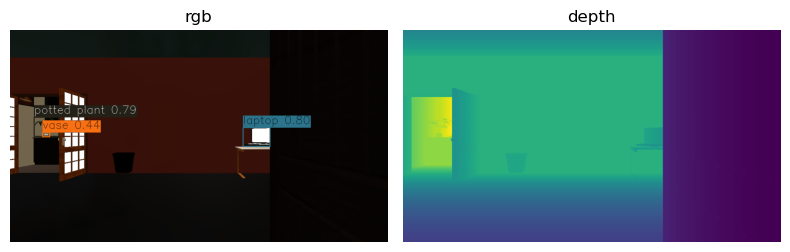

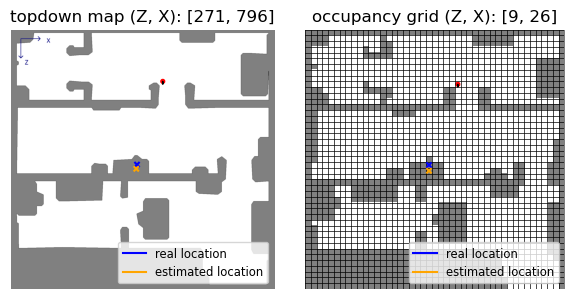


Target object <laptop> found after 41 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 41
Travelled distance: 8.24 m
Computed location error: 0.227 m

Simulation 19/100


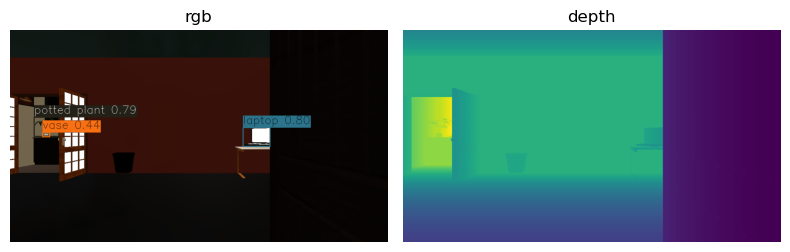

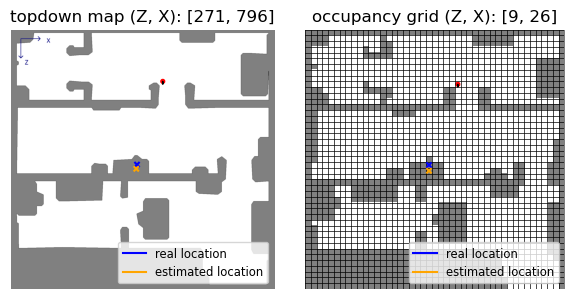


Target object <laptop> found after 178 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 178
Travelled distance: 40.85 m
Computed location error: 0.227 m

Simulation 20/100


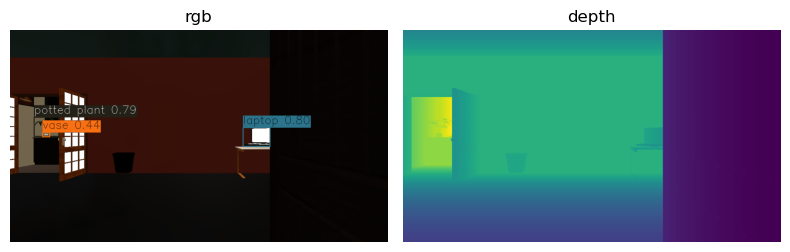

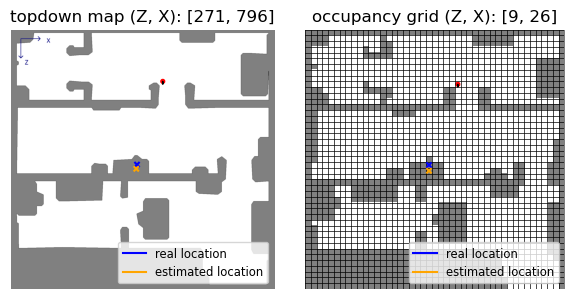


Target object <laptop> found after 140 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 140
Travelled distance: 31.70 m
Computed location error: 0.227 m

Simulation 21/100


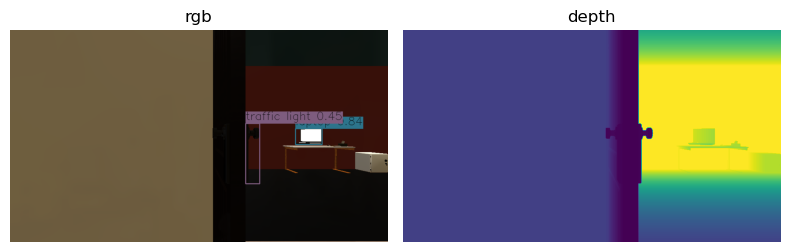

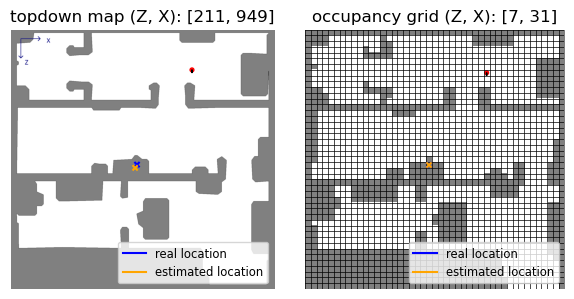


Target object <laptop> found after 42 actions!
Found location: [    -7.1425    0.020041      7.2259]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 42
Travelled distance: 8.25 m
Computed location error: 0.192 m

Simulation 22/100


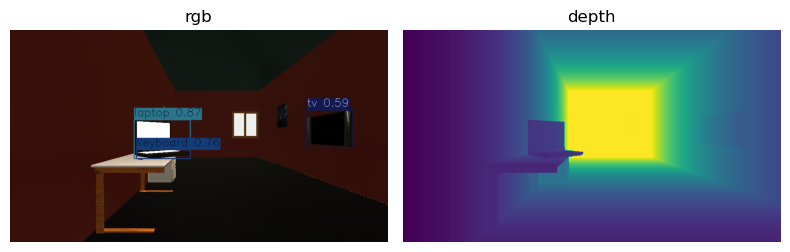

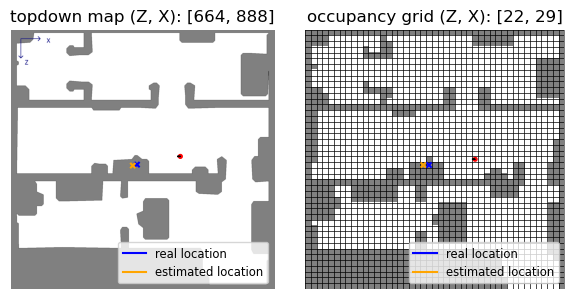


Target object <laptop> found after 199 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 199
Travelled distance: 45.44 m
Computed location error: 0.223 m

Simulation 23/100


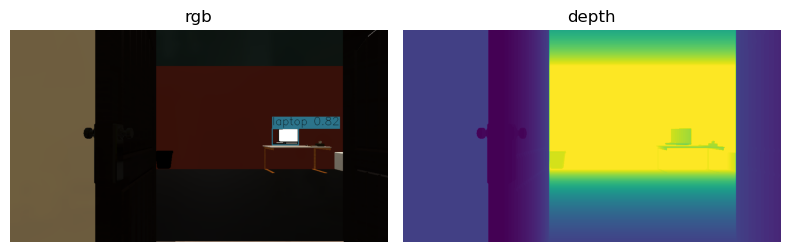

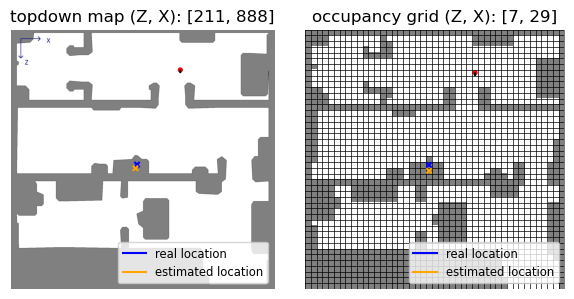


Target object <laptop> found after 119 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 119
Travelled distance: 27.81 m
Computed location error: 0.200 m

Simulation 24/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


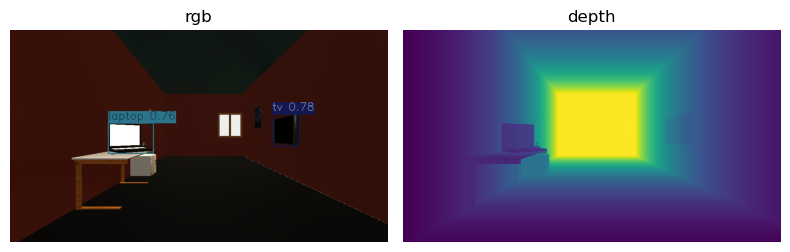

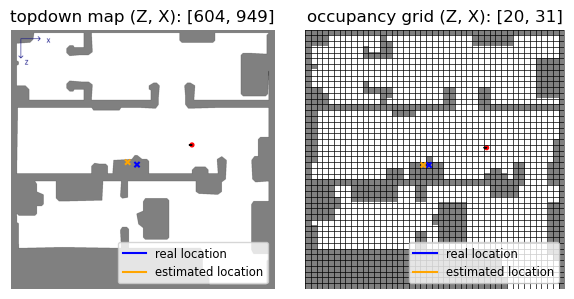


Target object <laptop> not found after 66 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 66
Travelled distance: 12.76 m
Computed location error: 0.507 m

Simulation 25/100


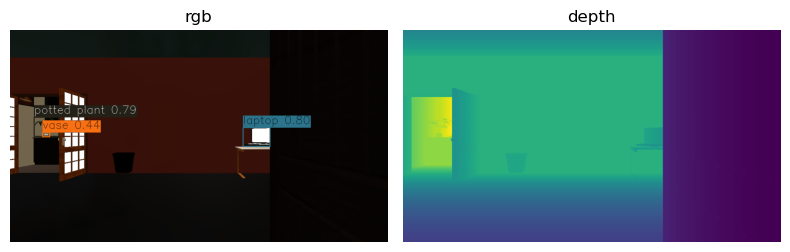

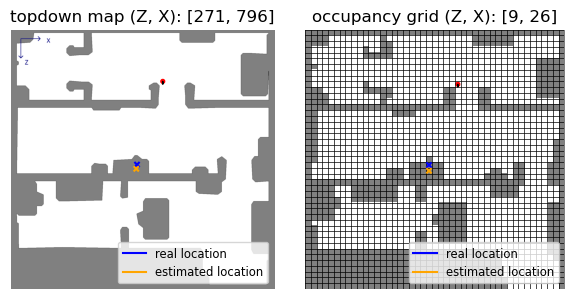


Target object <laptop> found after 43 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 43
Travelled distance: 8.86 m
Computed location error: 0.227 m

Simulation 26/100


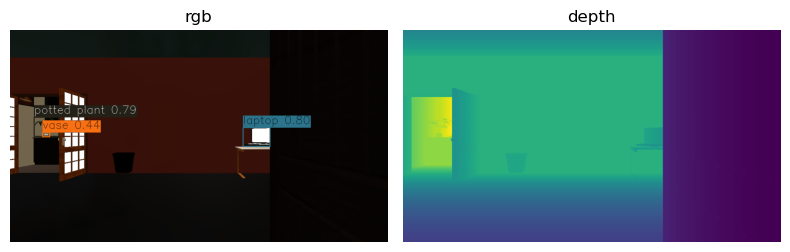

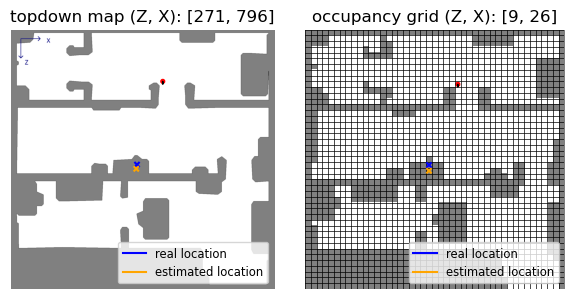


Target object <laptop> found after 118 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 118
Travelled distance: 25.66 m
Computed location error: 0.227 m

Simulation 27/100


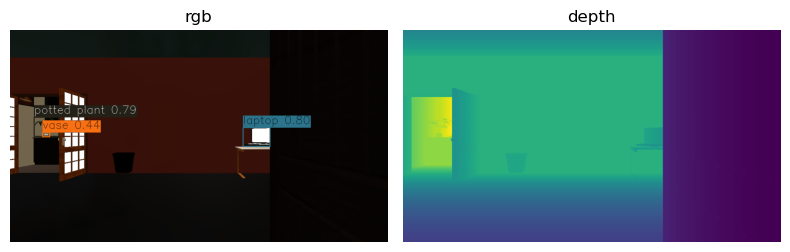

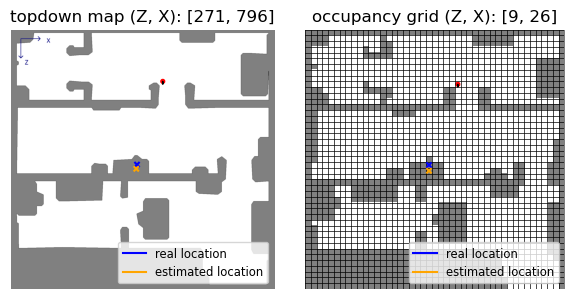


Target object <laptop> found after 40 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 40
Travelled distance: 8.24 m
Computed location error: 0.227 m

Simulation 28/100


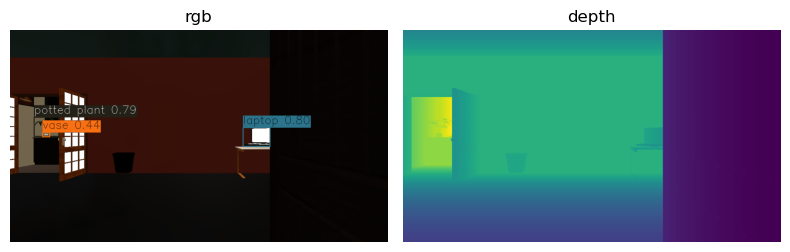

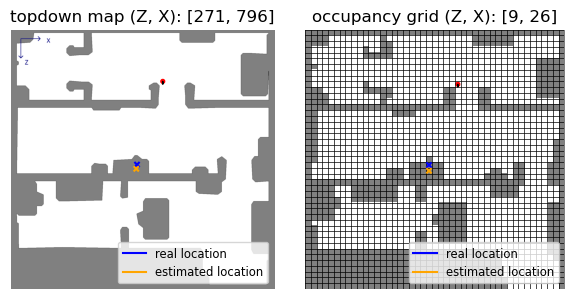


Target object <laptop> found after 120 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 120
Travelled distance: 25.96 m
Computed location error: 0.227 m

Simulation 29/100


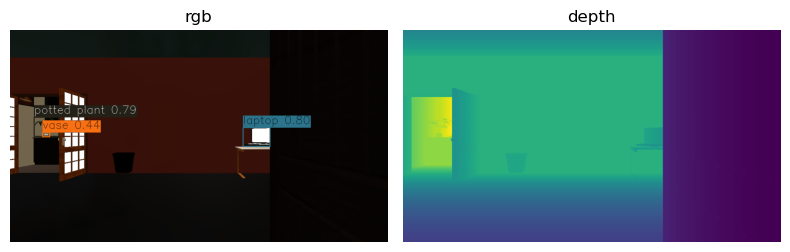

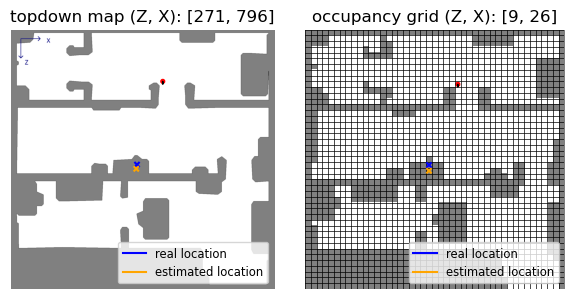


Target object <laptop> found after 143 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 143
Travelled distance: 31.12 m
Computed location error: 0.227 m

Simulation 30/100


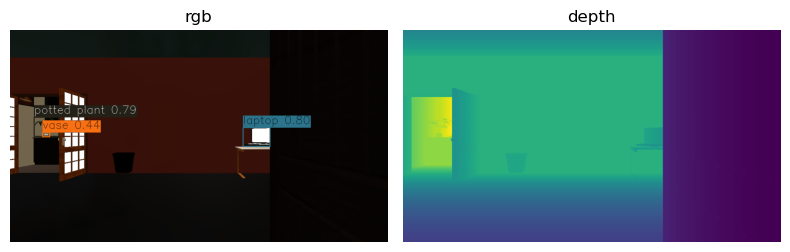

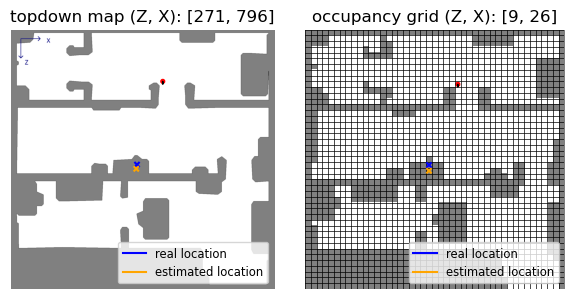


Target object <laptop> found after 47 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 47
Travelled distance: 10.08 m
Computed location error: 0.227 m

Simulation 31/100


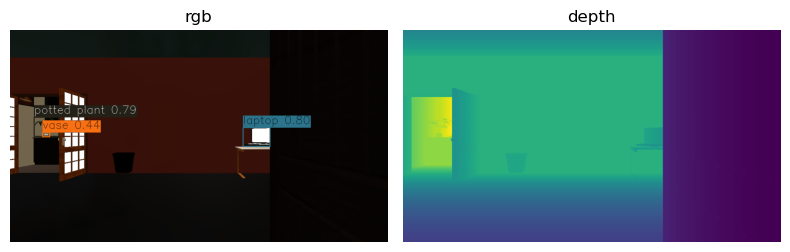

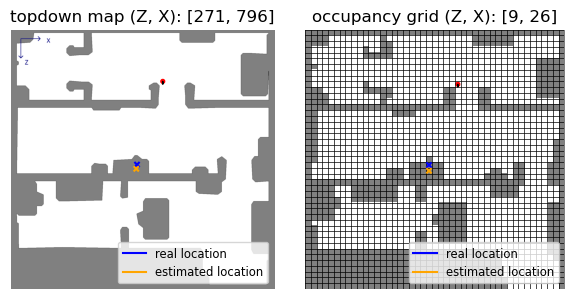


Target object <laptop> found after 39 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 39
Travelled distance: 8.25 m
Computed location error: 0.227 m

Simulation 32/100


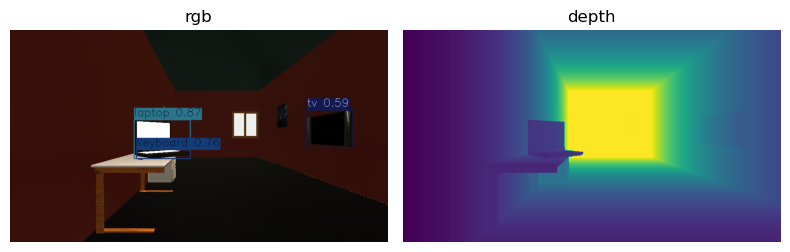

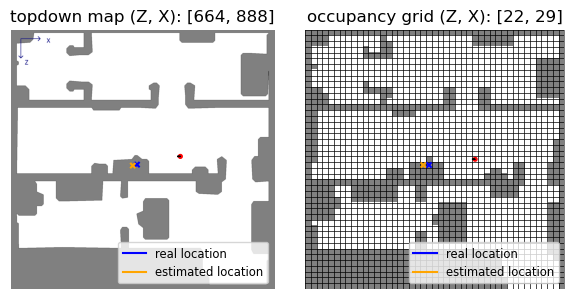


Target object <laptop> found after 164 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 164
Travelled distance: 36.30 m
Computed location error: 0.223 m

Simulation 33/100


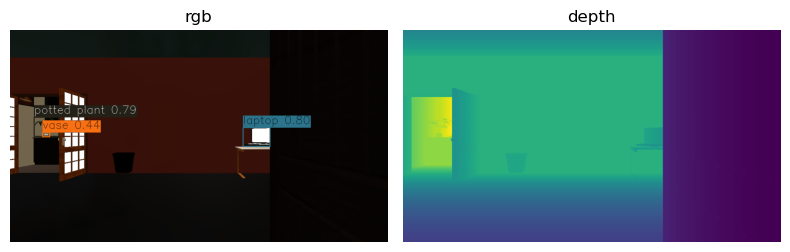

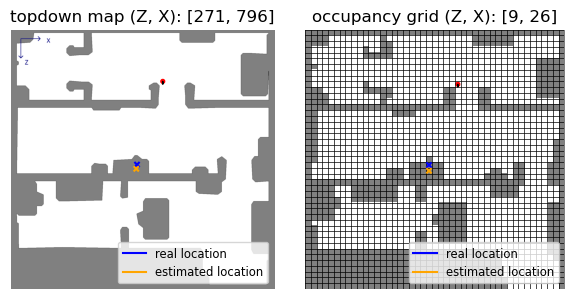


Target object <laptop> found after 169 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 169
Travelled distance: 36.56 m
Computed location error: 0.227 m

Simulation 34/100


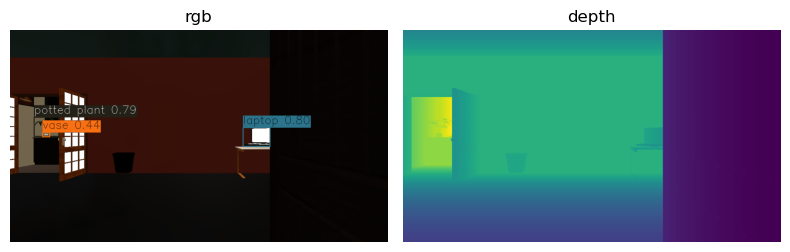

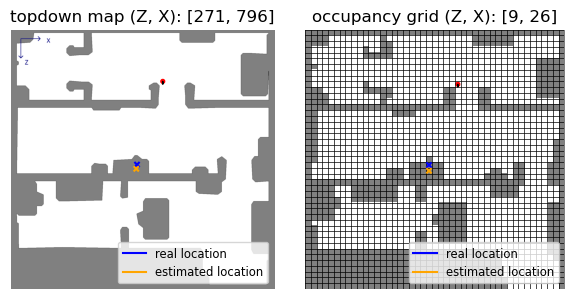


Target object <laptop> found after 167 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 167
Travelled distance: 36.25 m
Computed location error: 0.227 m

Simulation 35/100


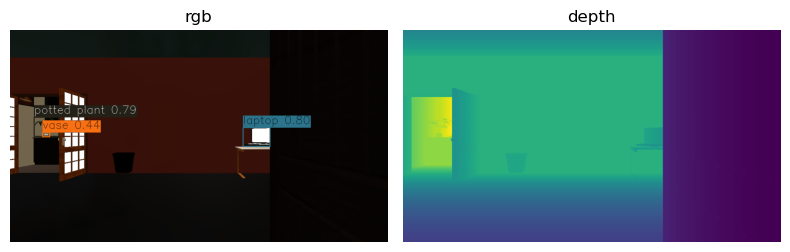

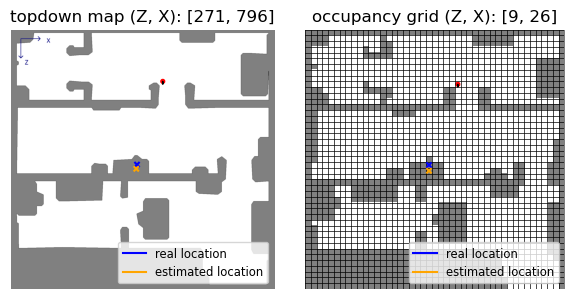


Target object <laptop> found after 44 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 44
Travelled distance: 9.47 m
Computed location error: 0.227 m

Simulation 36/100


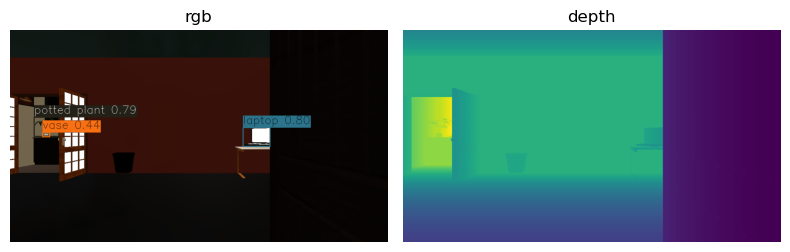

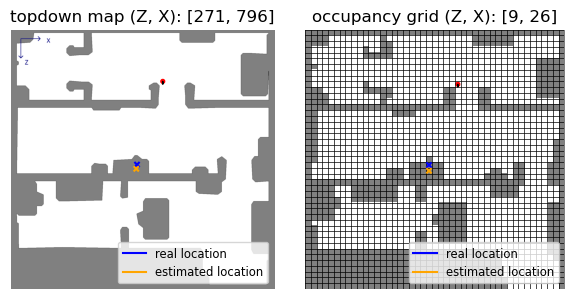


Target object <laptop> found after 56 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 56
Travelled distance: 11.93 m
Computed location error: 0.227 m

Simulation 37/100


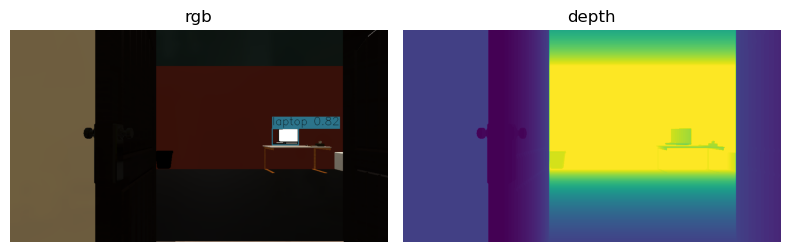

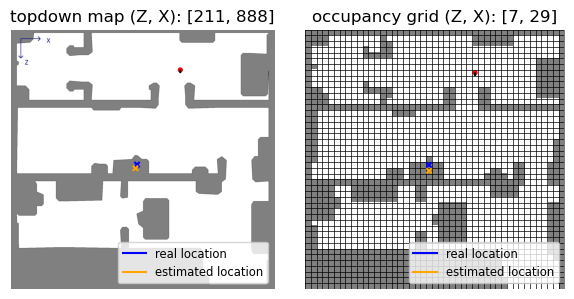


Target object <laptop> found after 263 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 263
Travelled distance: 60.45 m
Computed location error: 0.200 m

Simulation 38/100


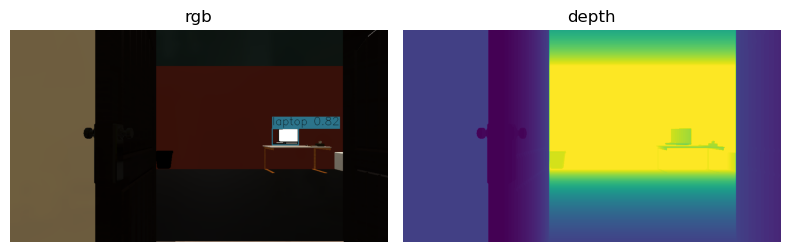

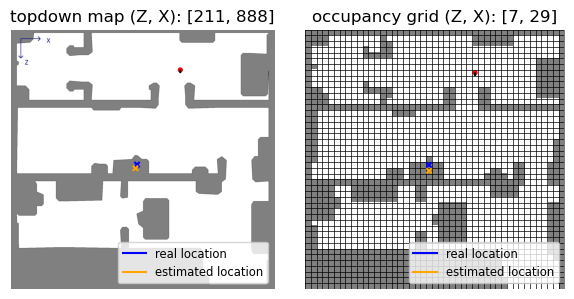


Target object <laptop> found after 107 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 107
Travelled distance: 23.83 m
Computed location error: 0.200 m

Simulation 39/100


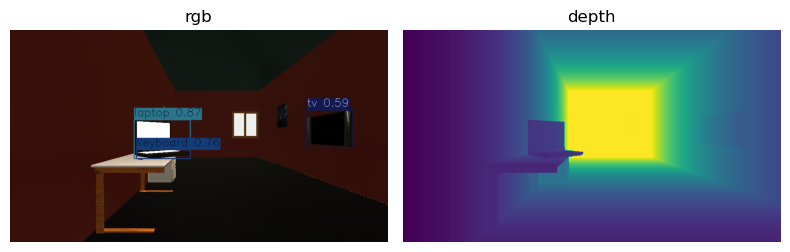

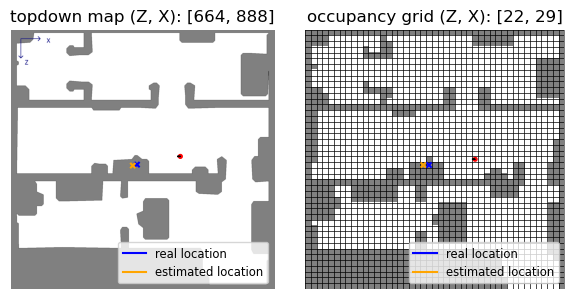


Target object <laptop> found after 202 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 202
Travelled distance: 46.04 m
Computed location error: 0.223 m

Simulation 40/100


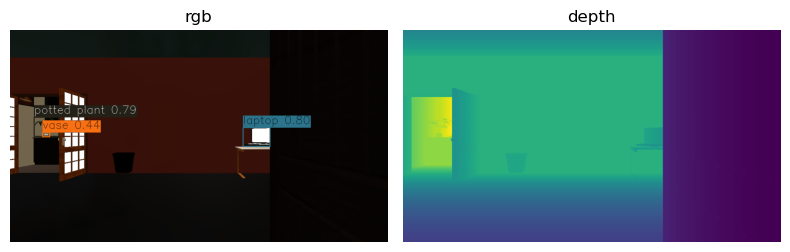

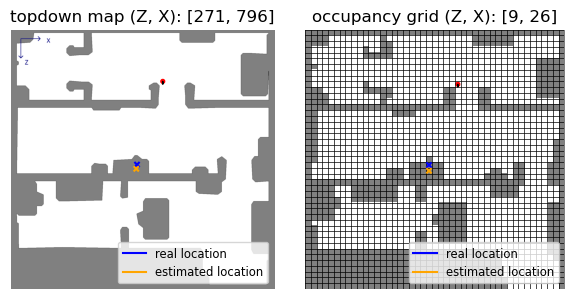


Target object <laptop> found after 184 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 184
Travelled distance: 39.35 m
Computed location error: 0.227 m

Simulation 41/100


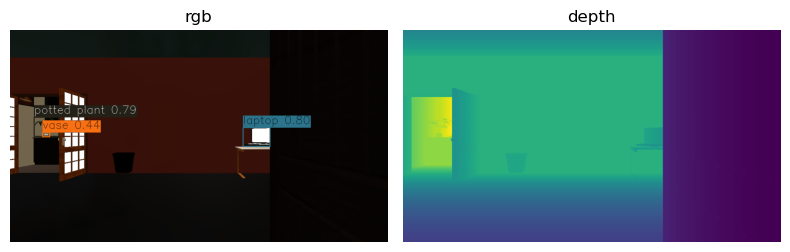

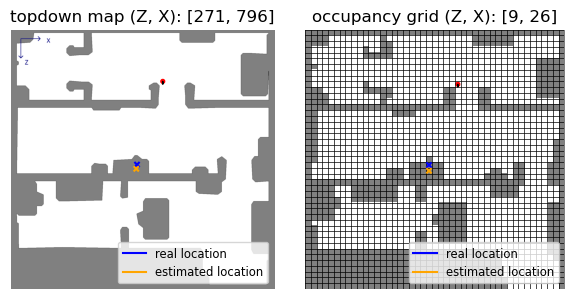


Target object <laptop> found after 45 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 45
Travelled distance: 9.15 m
Computed location error: 0.227 m

Simulation 42/100


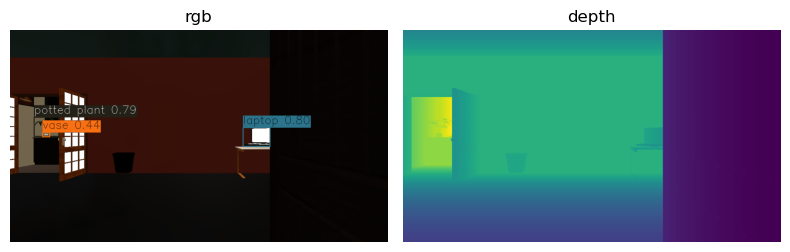

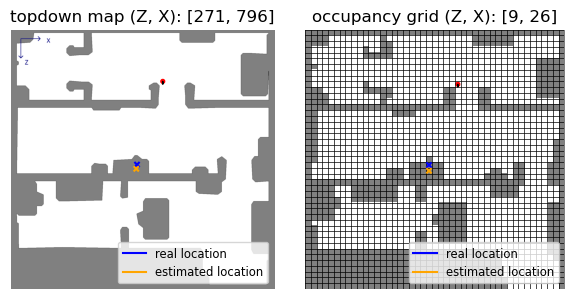


Target object <laptop> found after 42 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 42
Travelled distance: 8.24 m
Computed location error: 0.227 m

Simulation 43/100


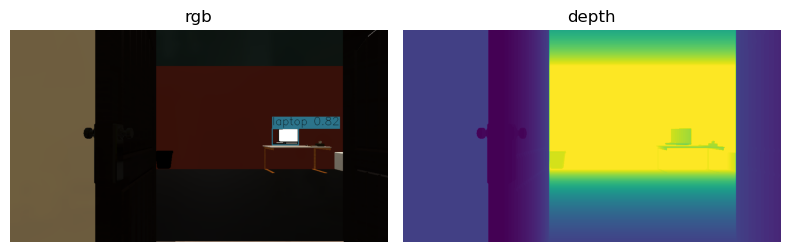

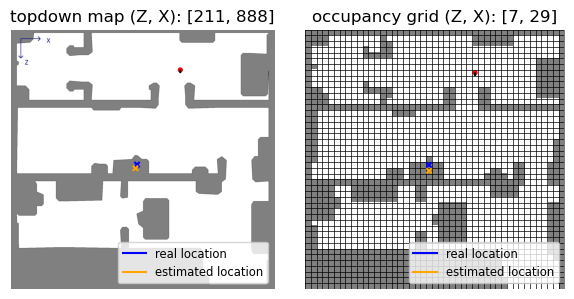


Target object <laptop> found after 262 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 262
Travelled distance: 60.14 m
Computed location error: 0.200 m

Simulation 44/100


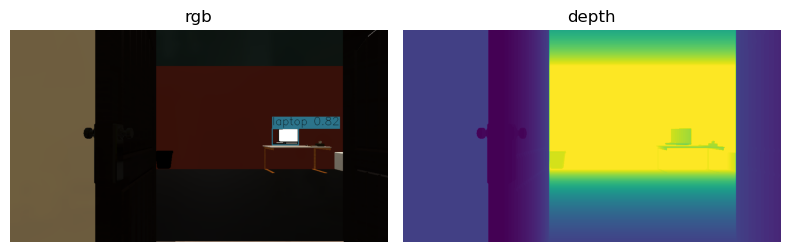

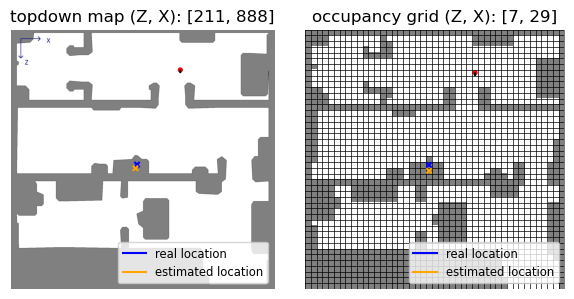


Target object <laptop> found after 265 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 265
Travelled distance: 60.75 m
Computed location error: 0.200 m

Simulation 45/100


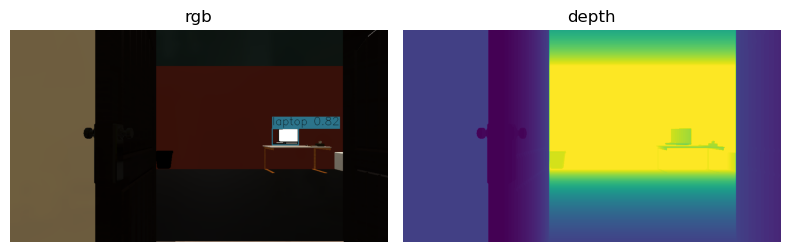

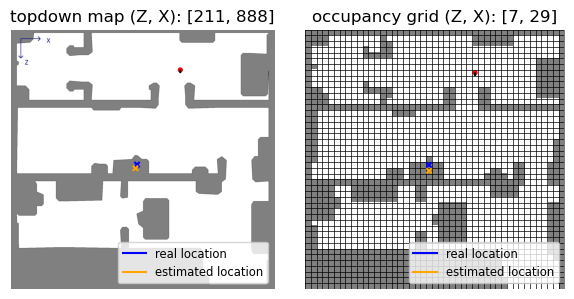


Target object <laptop> found after 109 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 109
Travelled distance: 24.75 m
Computed location error: 0.200 m

Simulation 46/100


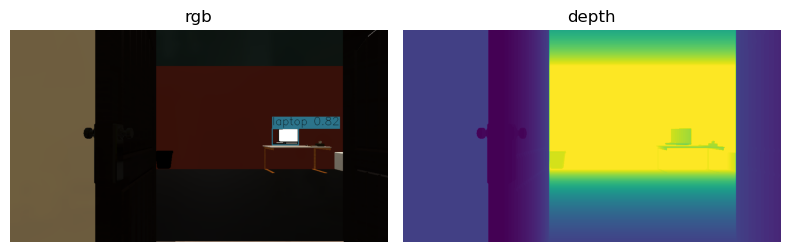

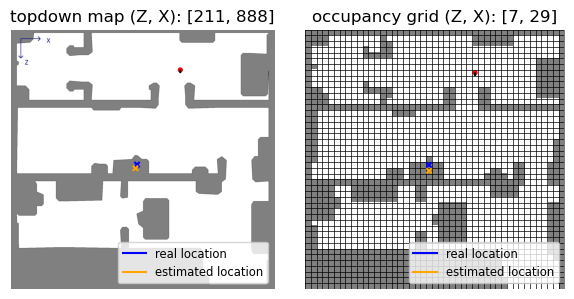


Target object <laptop> found after 172 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 172
Travelled distance: 39.42 m
Computed location error: 0.200 m

Simulation 47/100


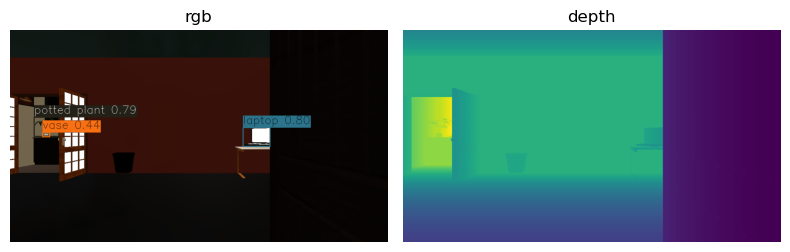

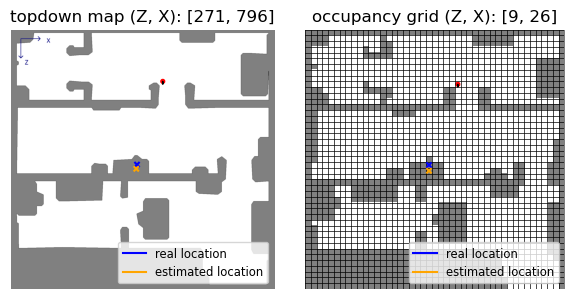


Target object <laptop> found after 30 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 5.79 m
Computed location error: 0.227 m

Simulation 48/100


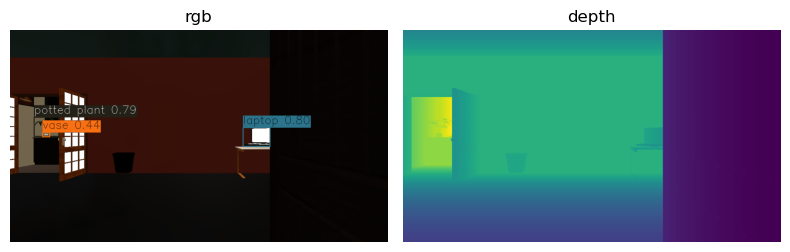

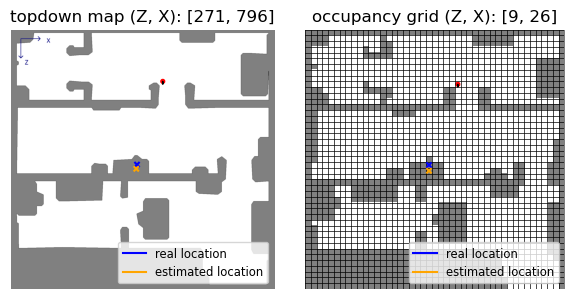


Target object <laptop> found after 176 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 176
Travelled distance: 38.43 m
Computed location error: 0.227 m

Simulation 49/100


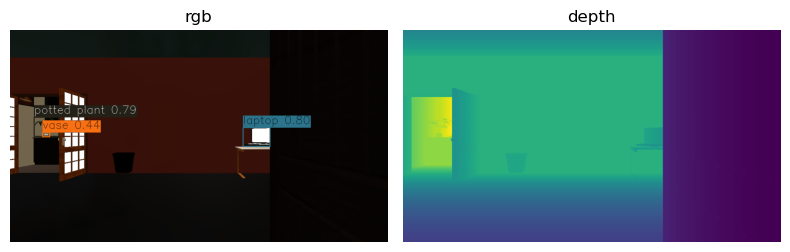

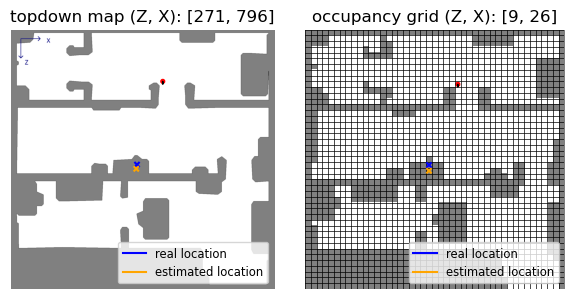


Target object <laptop> found after 144 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 144
Travelled distance: 32.30 m
Computed location error: 0.227 m

Simulation 50/100


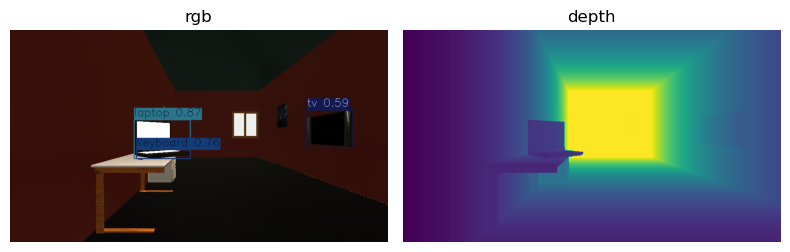

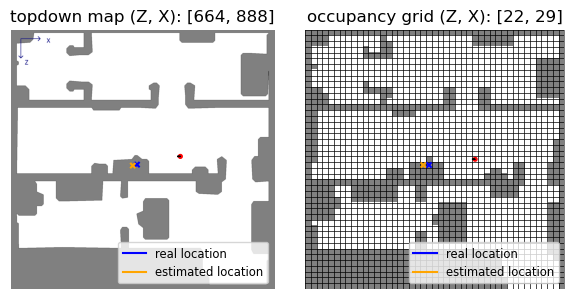


Target object <laptop> found after 171 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 171
Travelled distance: 39.00 m
Computed location error: 0.223 m

Simulation 51/100


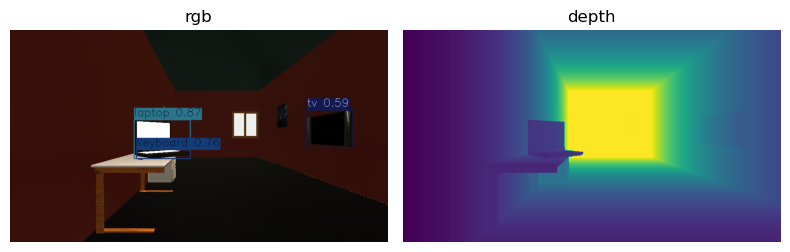

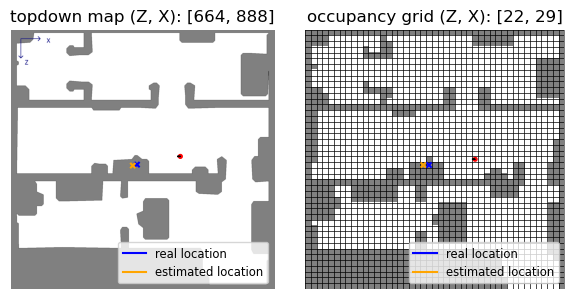


Target object <laptop> found after 160 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 160
Travelled distance: 35.70 m
Computed location error: 0.223 m

Simulation 52/100


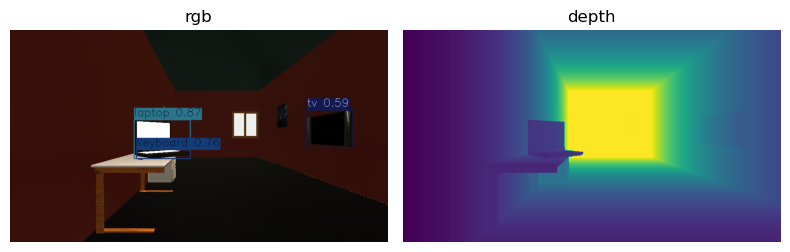

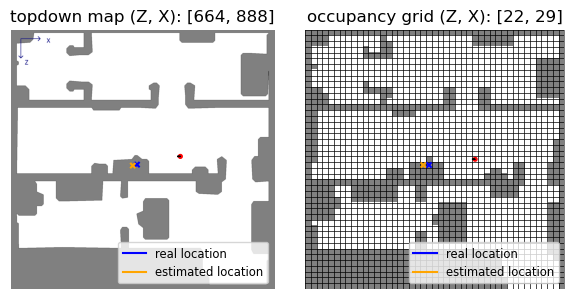


Target object <laptop> found after 175 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 175
Travelled distance: 39.61 m
Computed location error: 0.223 m

Simulation 53/100


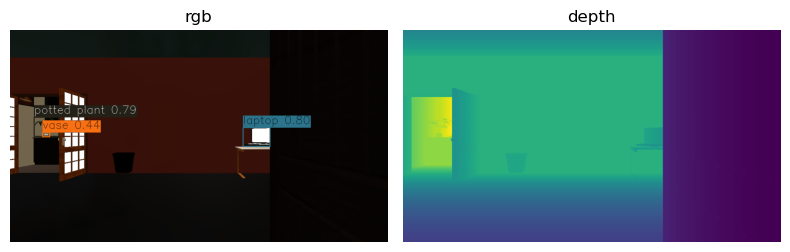

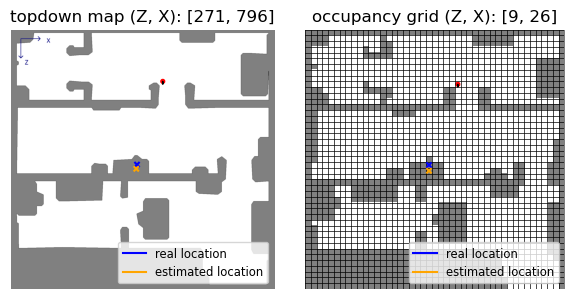


Target object <laptop> found after 67 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 67
Travelled distance: 14.36 m
Computed location error: 0.227 m

Simulation 54/100


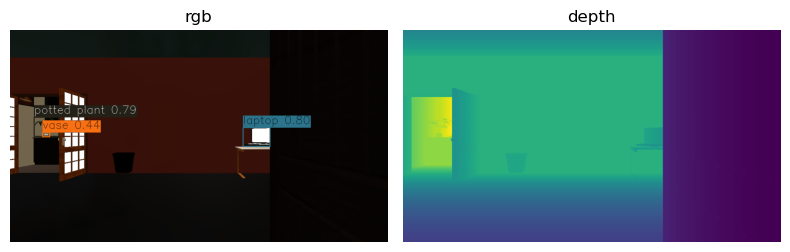

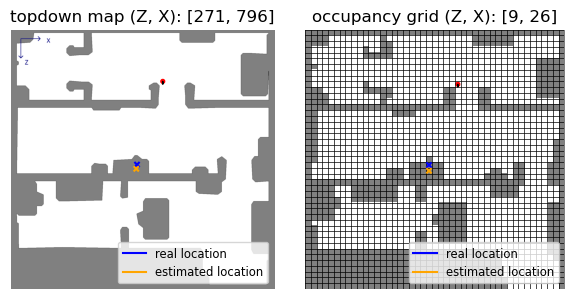


Target object <laptop> found after 63 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 63
Travelled distance: 13.76 m
Computed location error: 0.227 m

Simulation 55/100


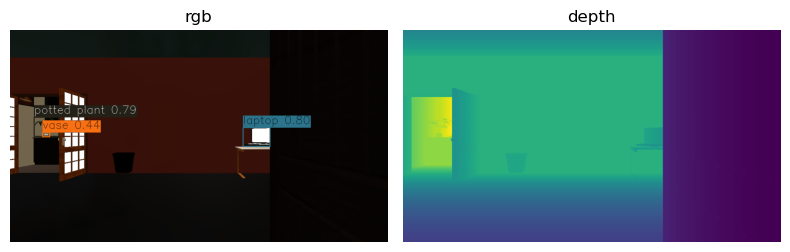

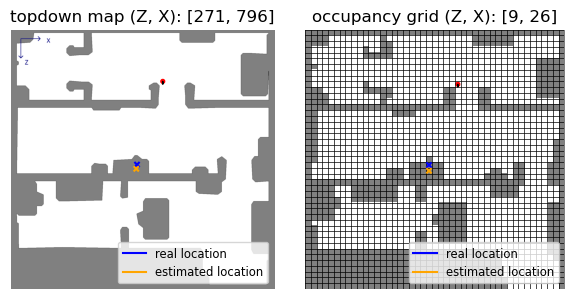


Target object <laptop> found after 41 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 41
Travelled distance: 7.94 m
Computed location error: 0.227 m

Simulation 56/100


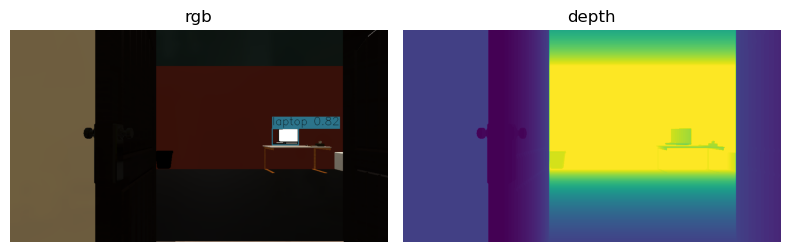

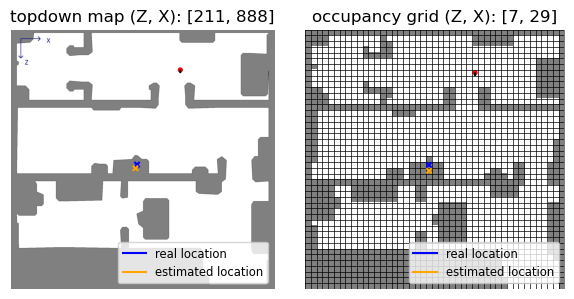


Target object <laptop> found after 102 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 102
Travelled distance: 23.22 m
Computed location error: 0.200 m

Simulation 57/100


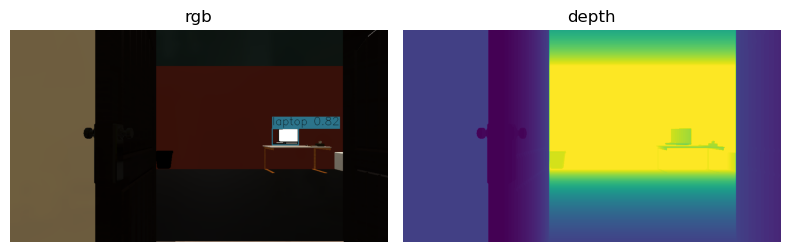

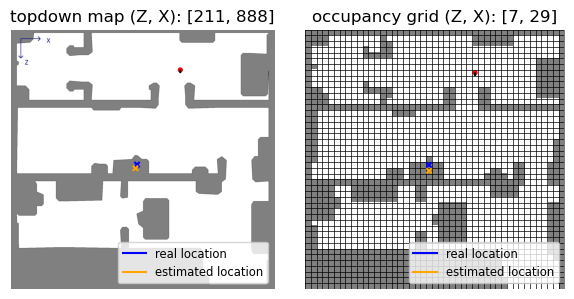


Target object <laptop> found after 323 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 323
Travelled distance: 75.98 m
Computed location error: 0.200 m

Simulation 58/100


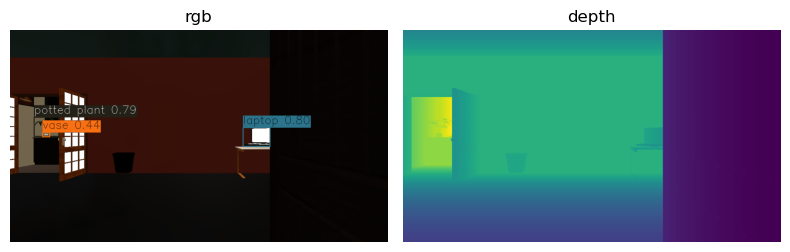

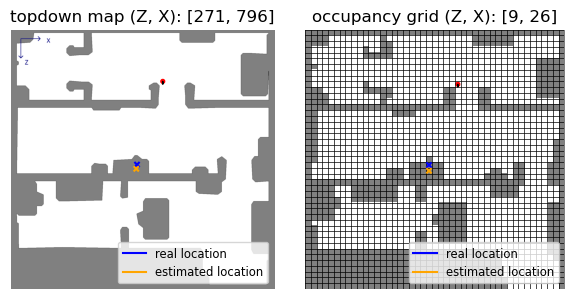


Target object <laptop> found after 42 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 42
Travelled distance: 9.15 m
Computed location error: 0.227 m

Simulation 59/100


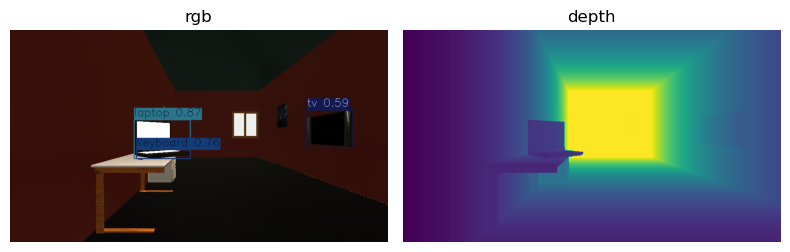

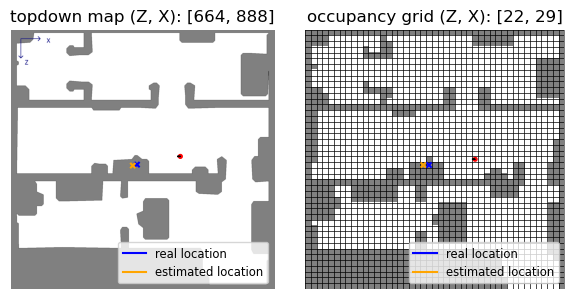


Target object <laptop> found after 162 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 162
Travelled distance: 36.61 m
Computed location error: 0.223 m

Simulation 60/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


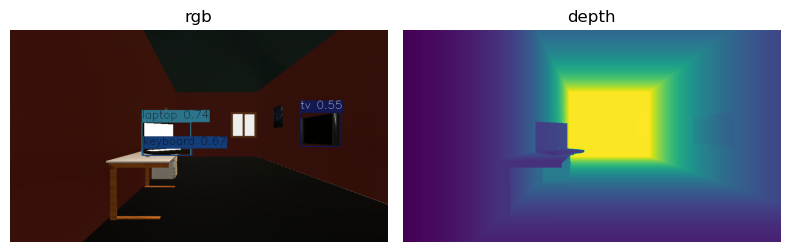

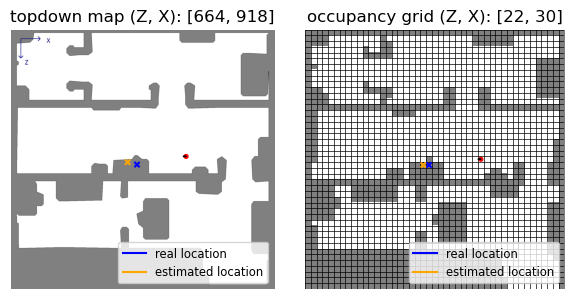


Target object <laptop> not found after 143 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 143
Travelled distance: 32.32 m
Computed location error: 0.507 m

Simulation 61/100


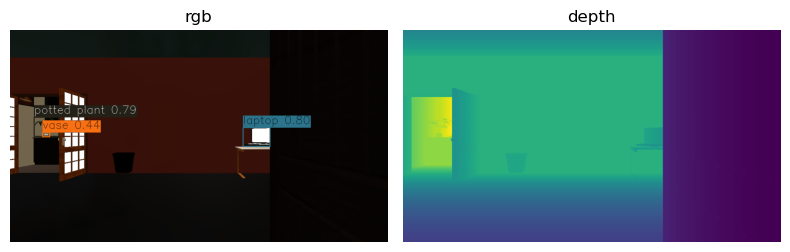

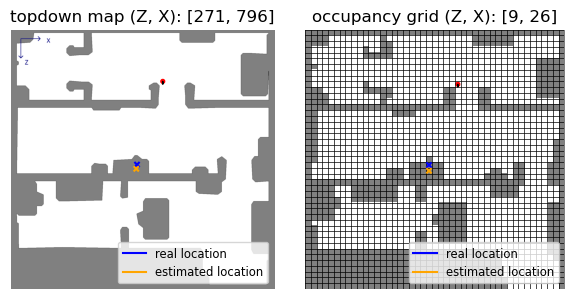


Target object <laptop> found after 180 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 180
Travelled distance: 38.73 m
Computed location error: 0.227 m

Simulation 62/100


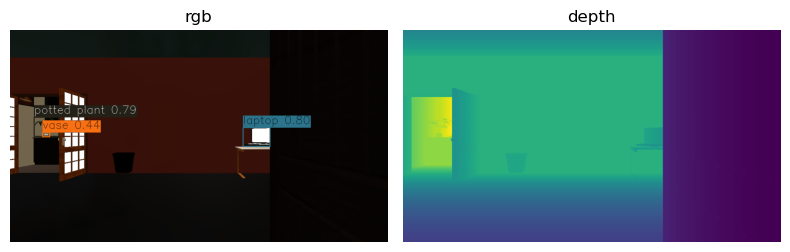

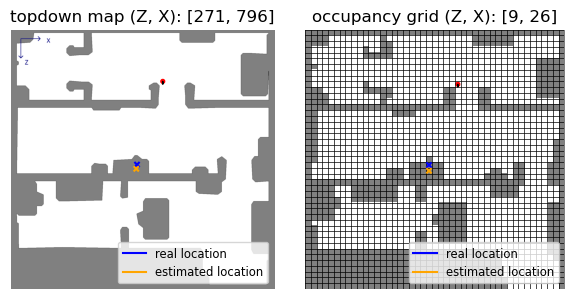


Target object <laptop> found after 121 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 121
Travelled distance: 26.26 m
Computed location error: 0.227 m

Simulation 63/100


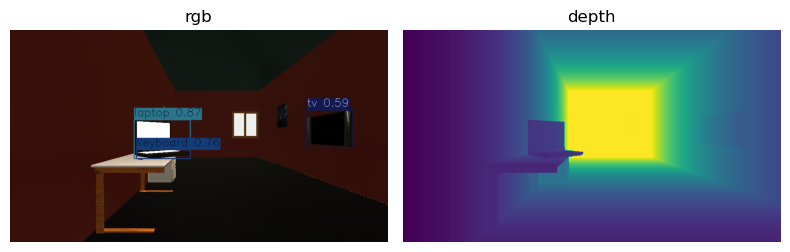

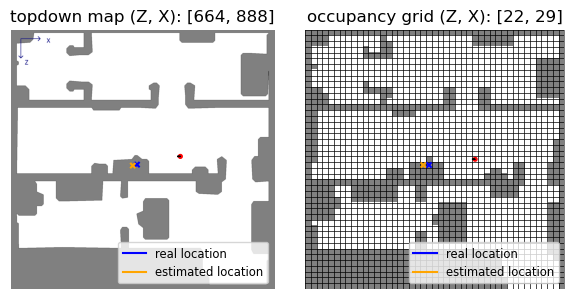


Target object <laptop> found after 160 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 160
Travelled distance: 35.70 m
Computed location error: 0.223 m

Simulation 64/100


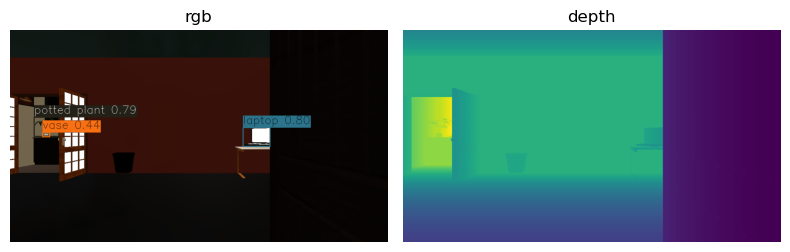

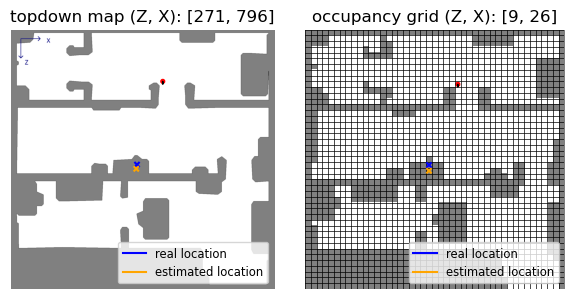


Target object <laptop> found after 141 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 141
Travelled distance: 32.01 m
Computed location error: 0.227 m

Simulation 65/100


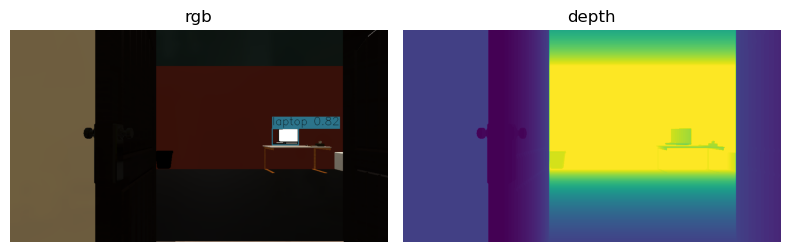

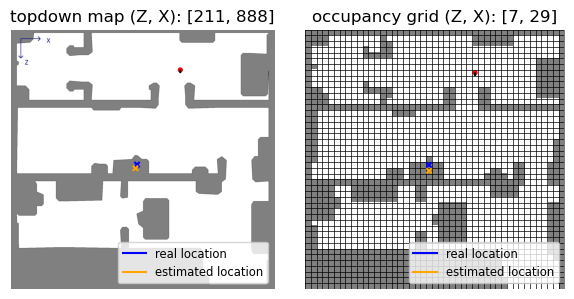


Target object <laptop> found after 329 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 329
Travelled distance: 75.38 m
Computed location error: 0.200 m

Simulation 66/100


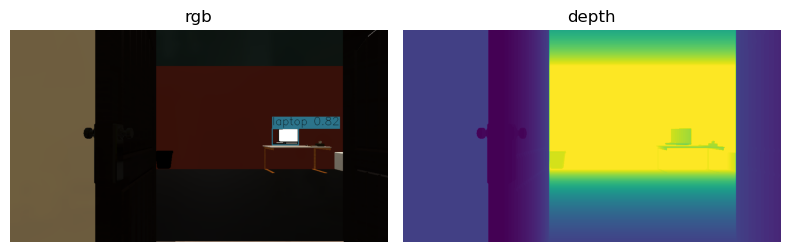

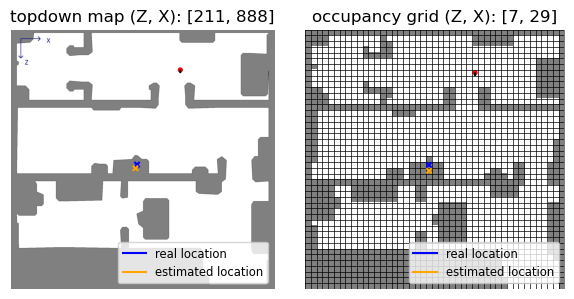


Target object <laptop> found after 144 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 144
Travelled distance: 32.08 m
Computed location error: 0.200 m

Simulation 67/100


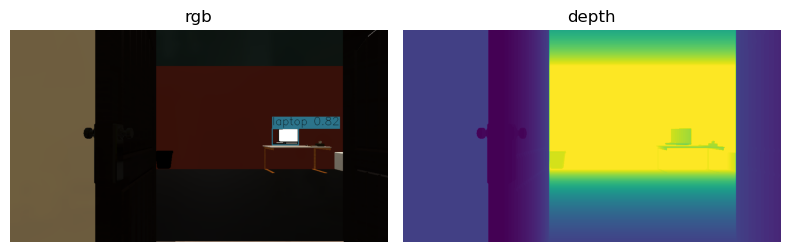

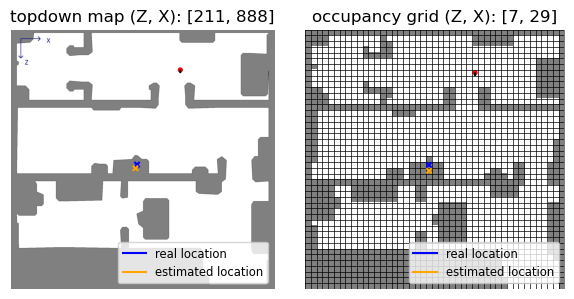


Target object <laptop> found after 145 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 145
Travelled distance: 32.99 m
Computed location error: 0.200 m

Simulation 68/100


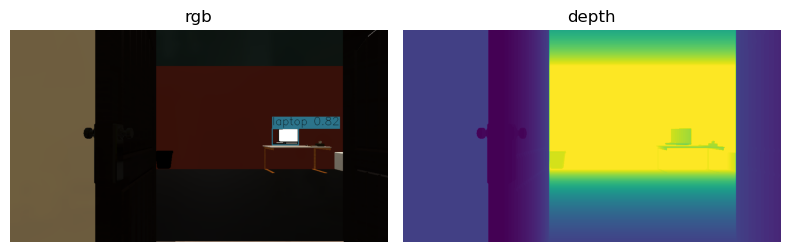

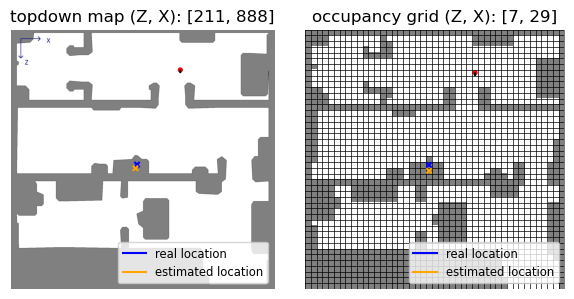


Target object <laptop> found after 242 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 242
Travelled distance: 55.85 m
Computed location error: 0.200 m

Simulation 69/100


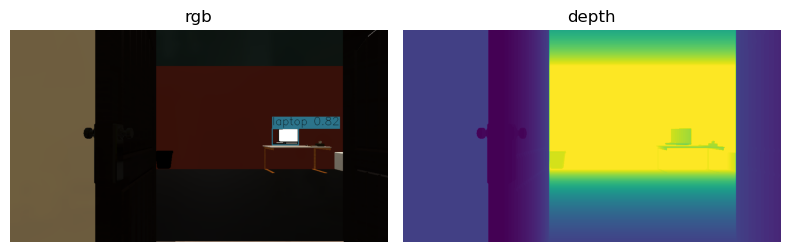

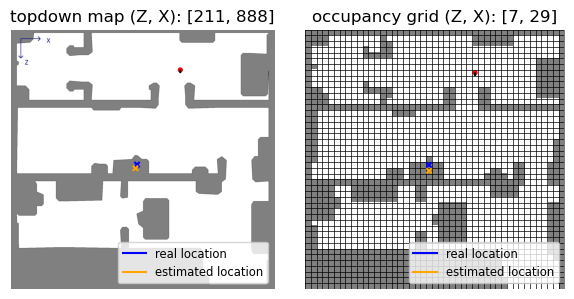


Target object <laptop> found after 104 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 104
Travelled distance: 23.83 m
Computed location error: 0.200 m

Simulation 70/100


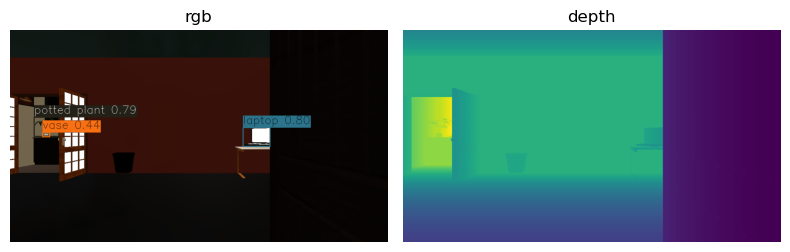

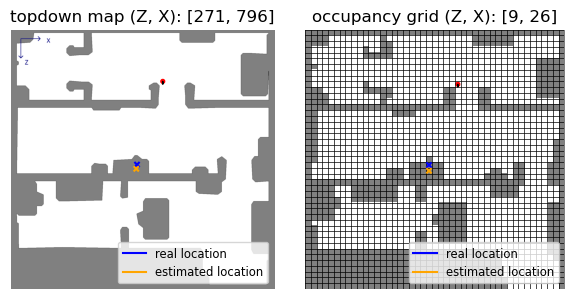


Target object <laptop> found after 38 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 38
Travelled distance: 7.03 m
Computed location error: 0.227 m

Simulation 71/100


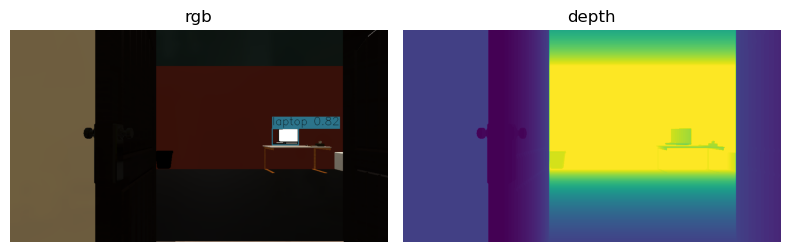

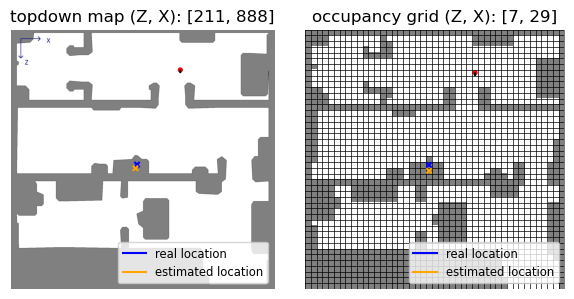


Target object <laptop> found after 111 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 111
Travelled distance: 25.05 m
Computed location error: 0.200 m

Simulation 72/100


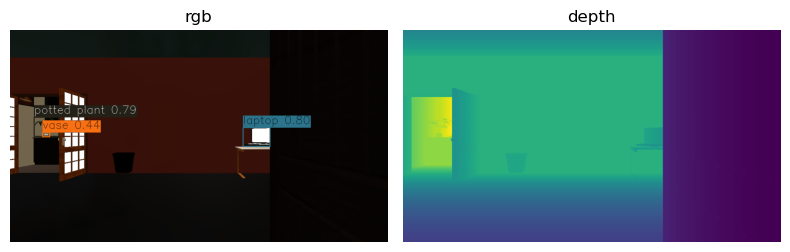

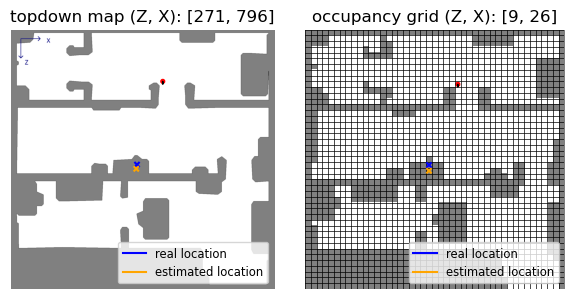


Target object <laptop> found after 39 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 39
Travelled distance: 7.64 m
Computed location error: 0.227 m

Simulation 73/100


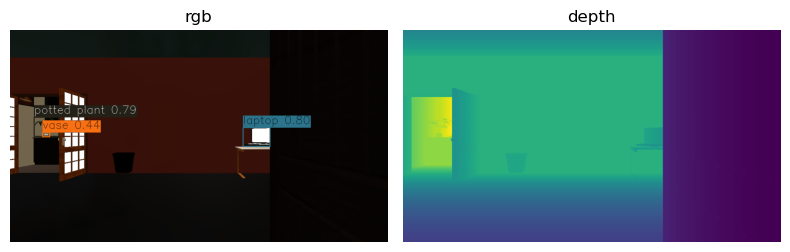

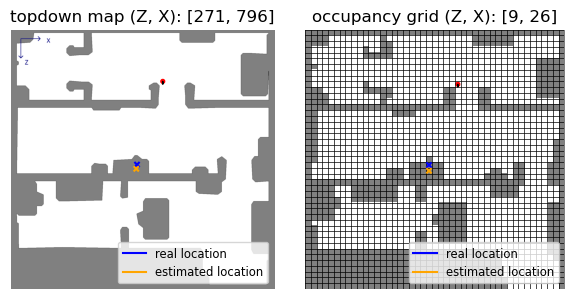


Target object <laptop> found after 46 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 46
Travelled distance: 9.46 m
Computed location error: 0.227 m

Simulation 74/100


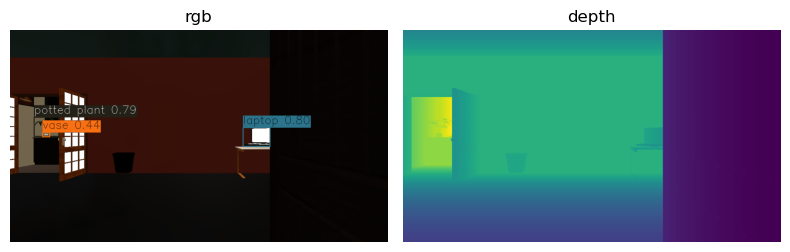

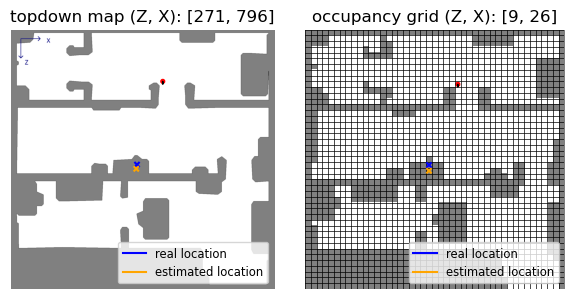


Target object <laptop> found after 41 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 41
Travelled distance: 7.94 m
Computed location error: 0.227 m

Simulation 75/100


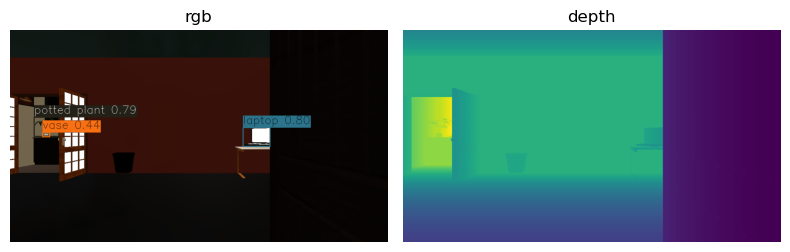

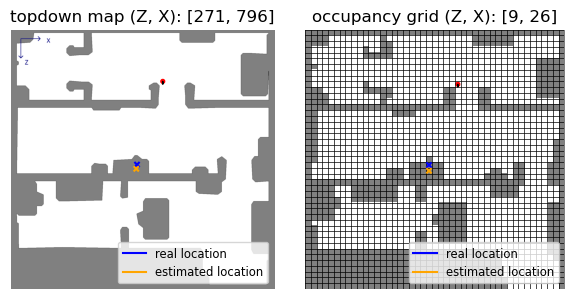


Target object <laptop> found after 49 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 49
Travelled distance: 9.46 m
Computed location error: 0.227 m

Simulation 76/100


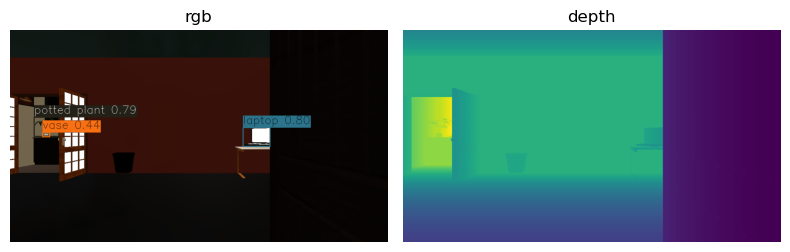

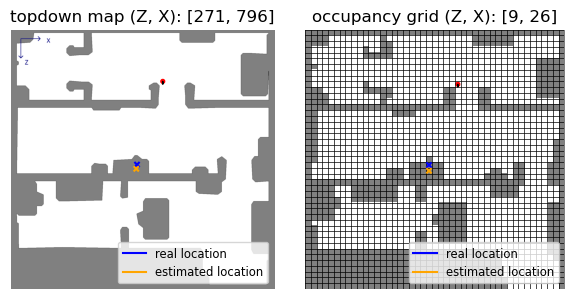


Target object <laptop> found after 46 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 46
Travelled distance: 9.78 m
Computed location error: 0.227 m

Simulation 77/100


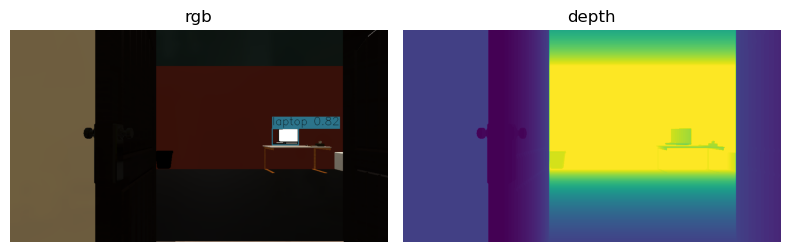

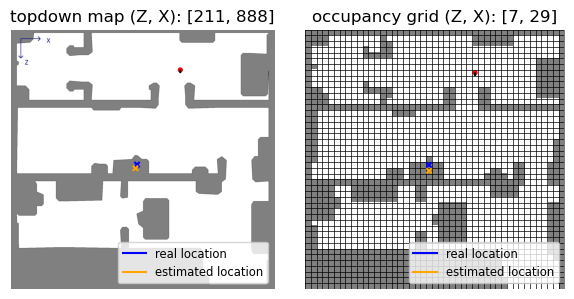


Target object <laptop> found after 247 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 247
Travelled distance: 56.46 m
Computed location error: 0.200 m

Simulation 78/100


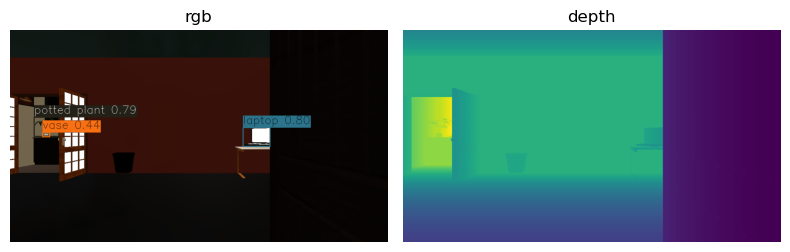

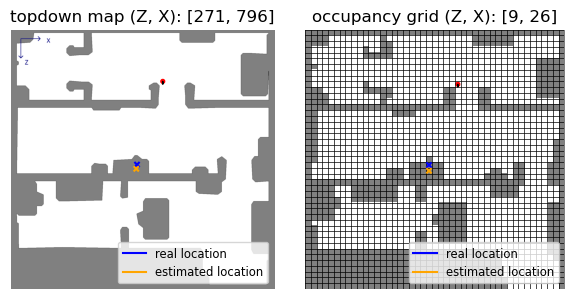


Target object <laptop> found after 143 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 143
Travelled distance: 32.61 m
Computed location error: 0.227 m

Simulation 79/100


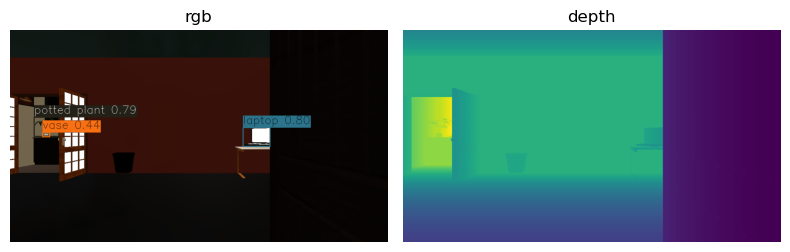

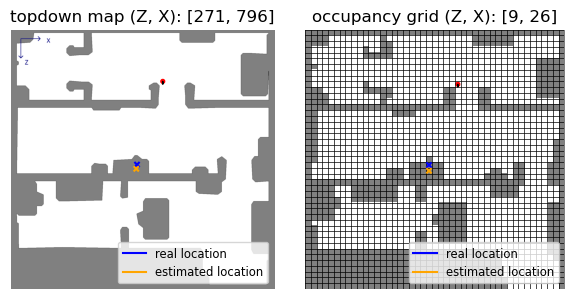


Target object <laptop> found after 177 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 177
Travelled distance: 40.85 m
Computed location error: 0.227 m

Simulation 80/100


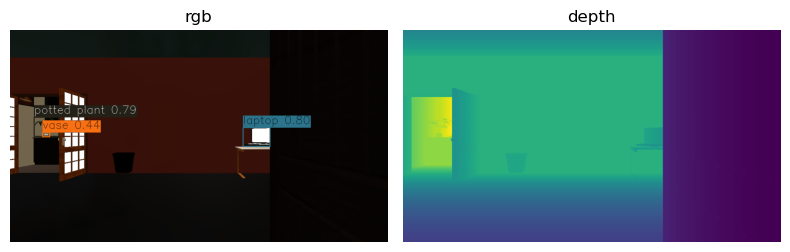

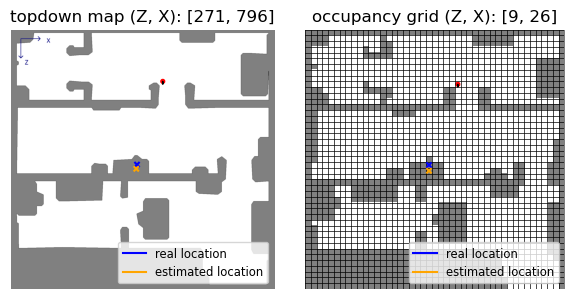


Target object <laptop> found after 37 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 37
Travelled distance: 7.64 m
Computed location error: 0.227 m

Simulation 81/100


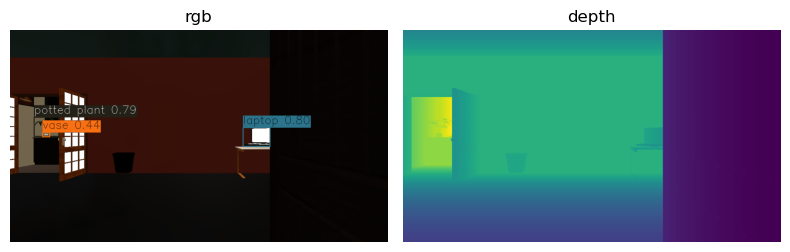

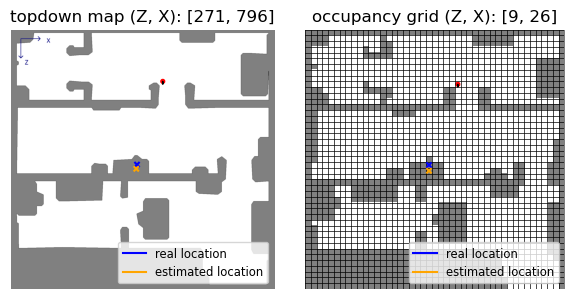


Target object <laptop> found after 149 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 149
Travelled distance: 32.33 m
Computed location error: 0.227 m

Simulation 82/100


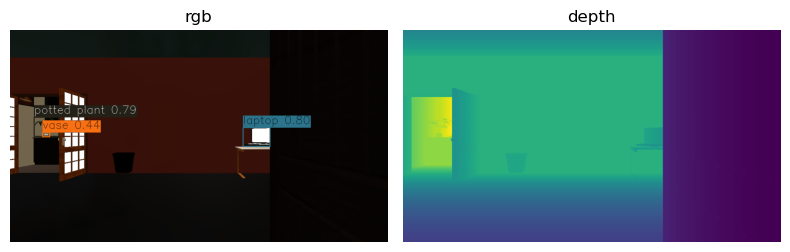

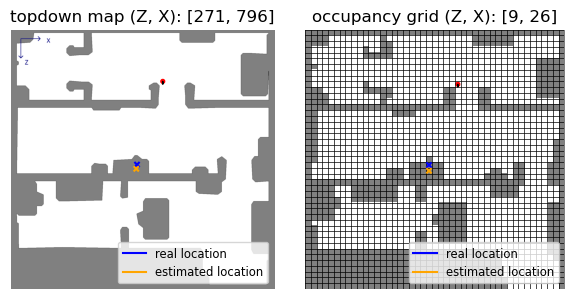


Target object <laptop> found after 43 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 43
Travelled distance: 8.54 m
Computed location error: 0.227 m

Simulation 83/100


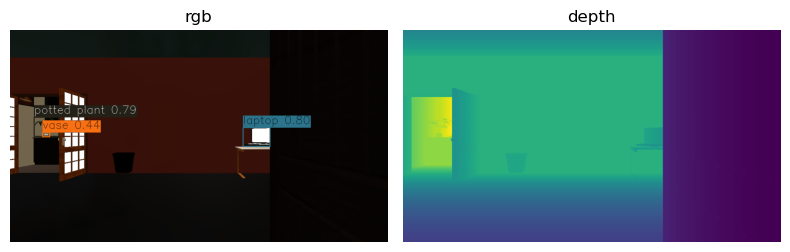

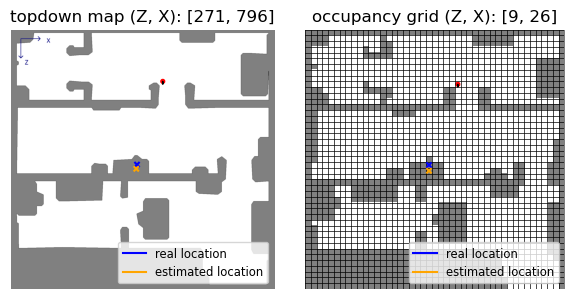


Target object <laptop> found after 141 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 141
Travelled distance: 31.11 m
Computed location error: 0.227 m

Simulation 84/100


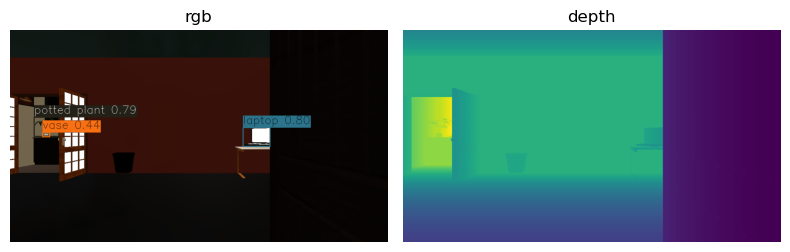

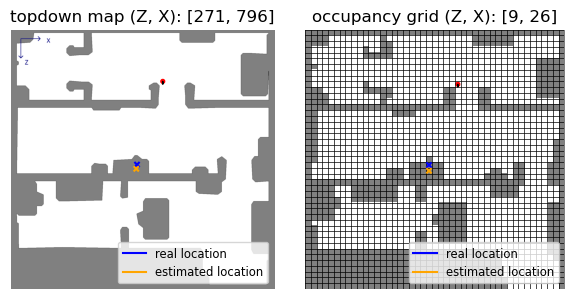


Target object <laptop> found after 179 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 179
Travelled distance: 40.85 m
Computed location error: 0.227 m

Simulation 85/100


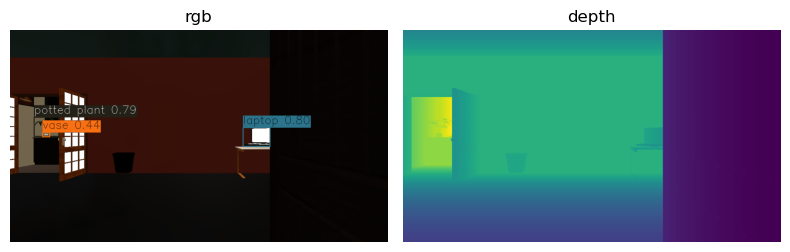

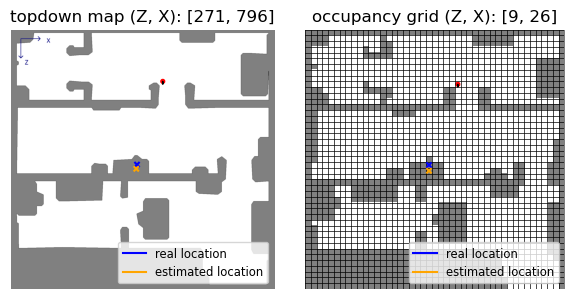


Target object <laptop> found after 30 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 30
Travelled distance: 6.72 m
Computed location error: 0.227 m

Simulation 86/100


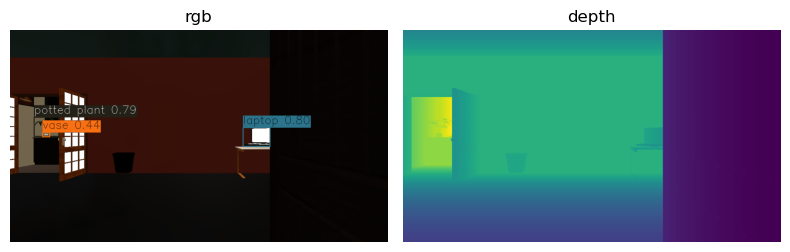

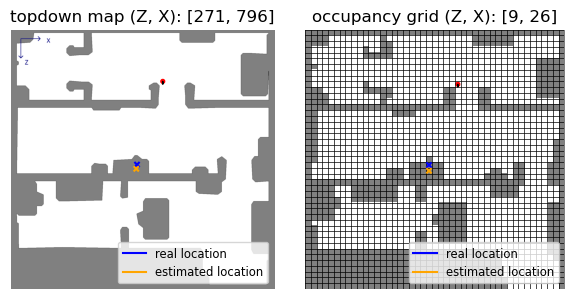


Target object <laptop> found after 36 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 36
Travelled distance: 7.03 m
Computed location error: 0.227 m

Simulation 87/100


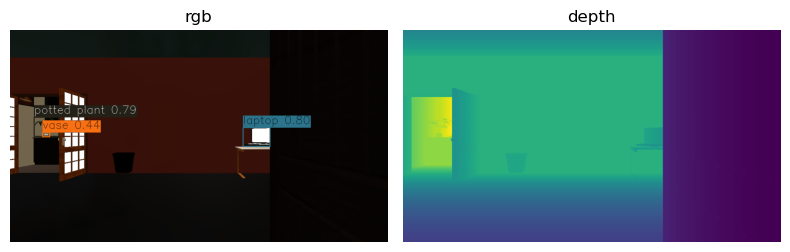

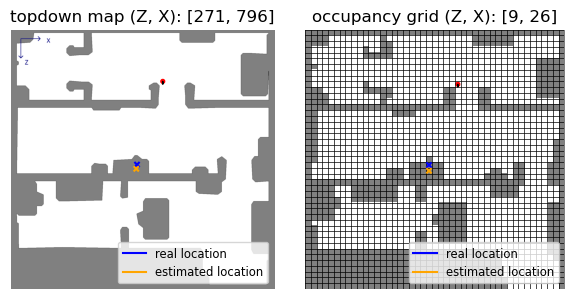


Target object <laptop> found after 46 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 46
Travelled distance: 8.85 m
Computed location error: 0.227 m

Simulation 88/100


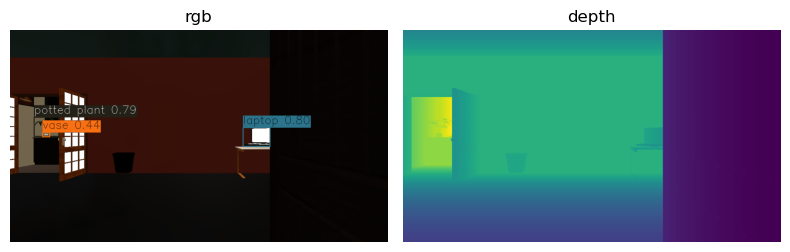

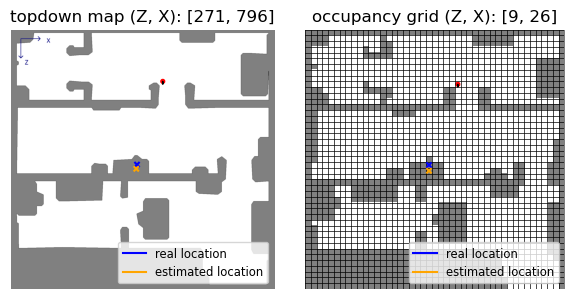


Target object <laptop> found after 168 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 168
Travelled distance: 36.26 m
Computed location error: 0.227 m

Simulation 89/100


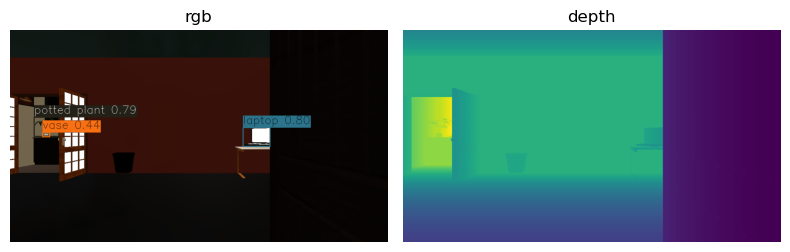

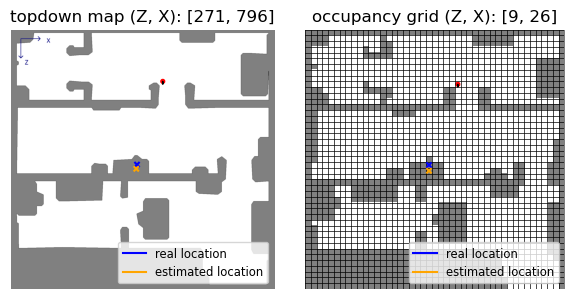


Target object <laptop> found after 63 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 63
Travelled distance: 13.14 m
Computed location error: 0.227 m

Simulation 90/100


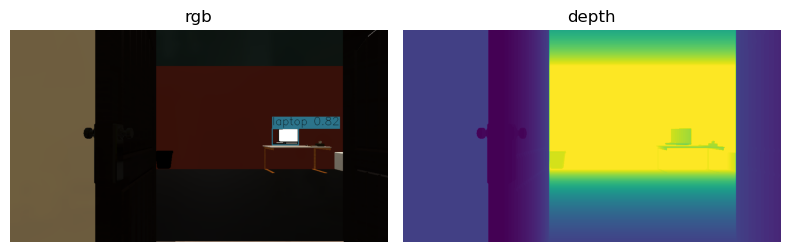

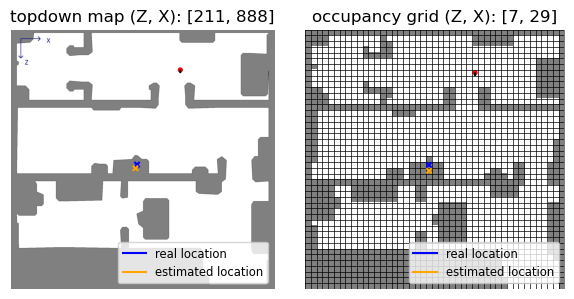


Target object <laptop> found after 326 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 326
Travelled distance: 75.68 m
Computed location error: 0.200 m

Simulation 91/100


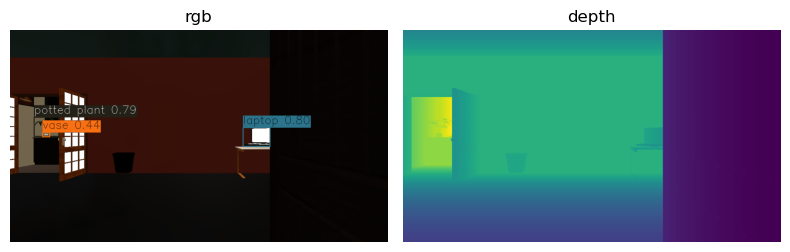

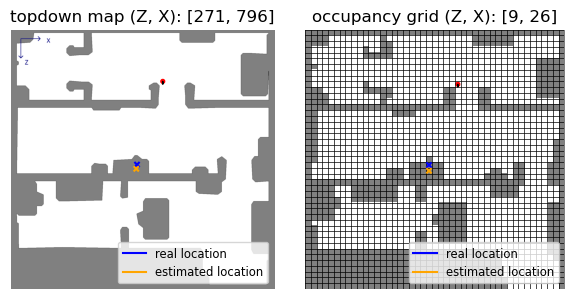


Target object <laptop> found after 36 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 36
Travelled distance: 7.95 m
Computed location error: 0.227 m

Simulation 92/100


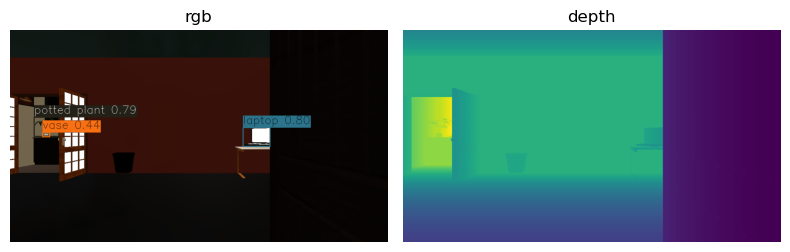

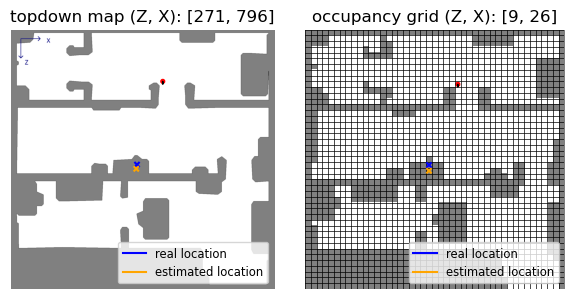


Target object <laptop> found after 25 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 25
Travelled distance: 4.27 m
Computed location error: 0.227 m

Simulation 93/100


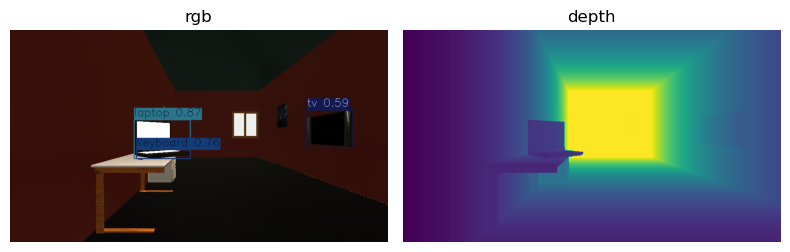

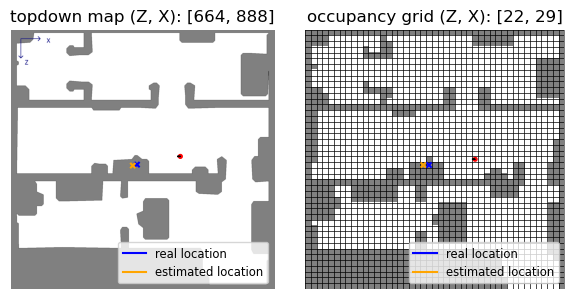


Target object <laptop> found after 138 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 138
Travelled distance: 31.41 m
Computed location error: 0.223 m

Simulation 94/100


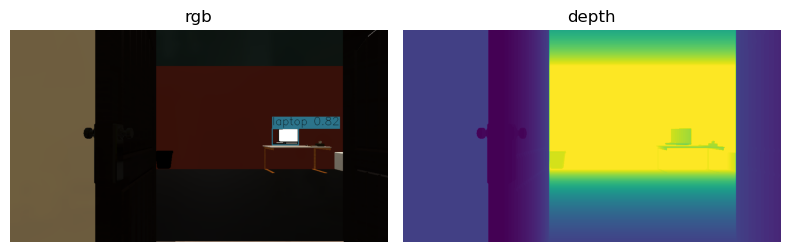

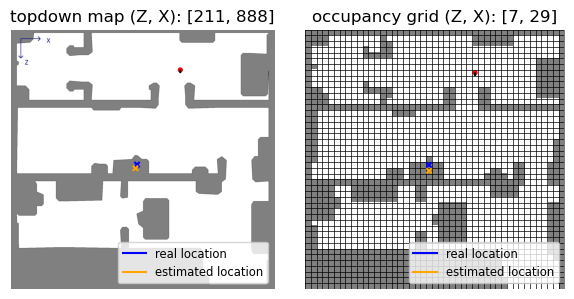


Target object <laptop> found after 240 actions!
Found location: [    -7.1227    0.030177      7.2457]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 240
Travelled distance: 55.55 m
Computed location error: 0.200 m

Simulation 95/100


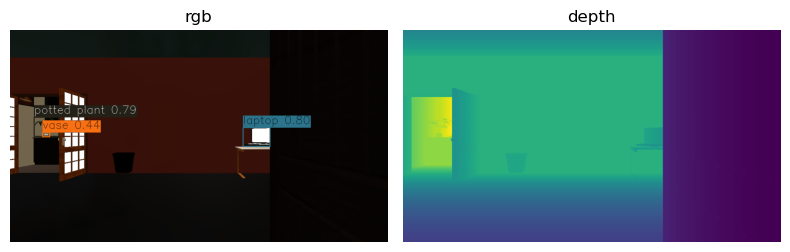

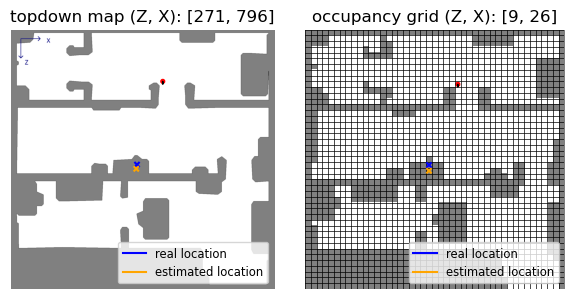


Target object <laptop> found after 151 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 151
Travelled distance: 32.63 m
Computed location error: 0.227 m

Simulation 96/100


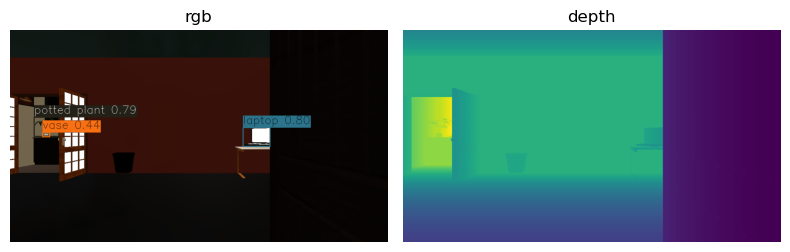

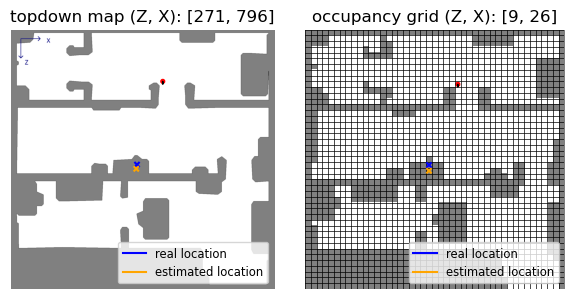


Target object <laptop> found after 187 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 187
Travelled distance: 42.49 m
Computed location error: 0.227 m

Simulation 97/100


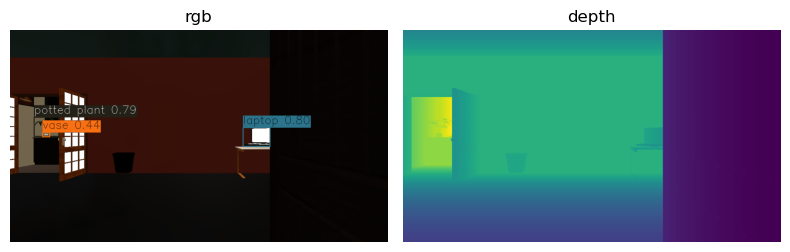

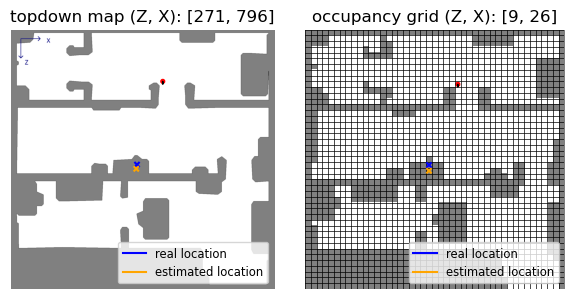


Target object <laptop> found after 37 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 37
Travelled distance: 7.63 m
Computed location error: 0.227 m

Simulation 98/100


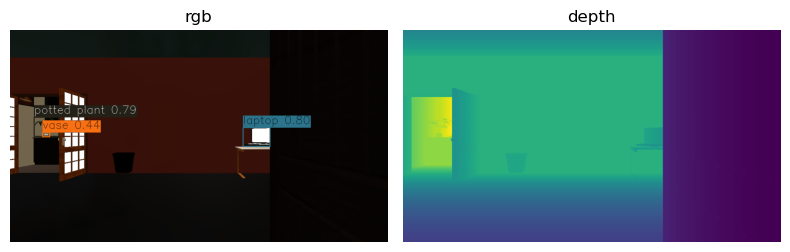

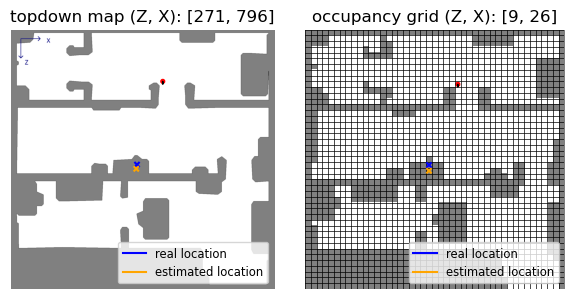


Target object <laptop> found after 144 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 144
Travelled distance: 31.73 m
Computed location error: 0.227 m

Simulation 99/100


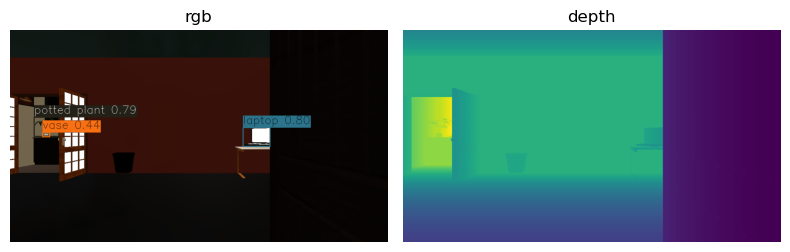

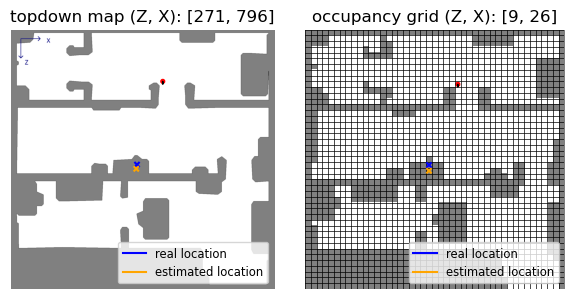


Target object <laptop> found after 137 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 137
Travelled distance: 31.39 m
Computed location error: 0.227 m

Simulation 100/100

Location error 0.507 m exceeds threshold 0.5 m. FAILURE!


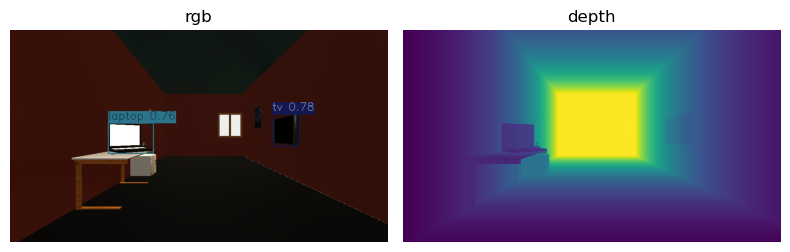

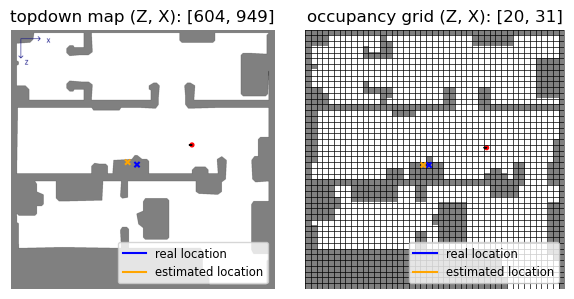


Target object <laptop> not found after 40 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 40
Travelled distance: 7.90 m
Computed location error: 0.507 m


In [8]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize belief map: NUM_CLASSES + 1 for the background 
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
    w_e, w_d, w_p = 0.4, 0.5, 0.1  # Weights for entropy, distance, and target probability
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

    # Print simulation 
    print(f"\nSimulation {index+1}/{len(starting_grid_positions)}")

    # Main simulation loop
    while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
        
        # Cluster grid map
        cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
        cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
        centroids = cluster_centers.copy() # For displaying logic
        cluster_occ_cells_map = simtools.assign_cluster_centers_to_cells(grid_occ_cells, cluster_centers, grid_free_cells)

        # Entropy map
        entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

        # Display the simulation state
        #simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

        # Move into each cluster center
        while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

            # Computes scores for each cluster center
            distances, avg_entropies, avg_target_probs = [], [], []
            for cluster_center in cluster_centers:
                # Path distance 
                distance, _ = simtools.compute_path(grid_position, cluster_center, grid_free_cells)
                distances.append(distance)

                # Average entropy of the cluster
                avg_entropy = simtools.compute_average_entropy(belief_map, cluster_occ_cells_map[tuple(cluster_center)])
                avg_entropies.append(avg_entropy)

                # Target probability in the cluster surroundings
                avg_target_prob = simtools.compute_max_target_probability(belief_map, cluster_occ_cells_map[tuple(cluster_center)], indoor_objects.index(TARGET_OBJECT))
                avg_target_probs.append(avg_target_prob)

            # Normalize score components
            distances, avg_entropies, avg_target_probs = np.array(distances), np.array(avg_entropies), np.array(avg_target_probs)
            distances = (distances-np.min(distances)) / (np.max(distances)-np.min(distances)) if np.max(distances) != np.min(distances) else np.zeros_like(distances)
            avg_entropies = (avg_entropies-np.min(avg_entropies)) / (np.max(avg_entropies)-np.min(avg_entropies)) if abs(np.max(avg_entropies) - np.min(avg_entropies)) > 1e-5 else np.zeros_like(avg_entropies)
            avg_target_probs = (avg_target_probs-np.min(avg_target_probs)) / (np.max(avg_target_probs)-np.min(avg_target_probs)) if np.max(avg_target_probs) != np.min(avg_target_probs) else np.zeros_like(avg_target_probs)

            # Select best cluster center based on the scores
            scores = w_e * avg_entropies + w_d * (1-distances) + w_p * avg_target_probs
            max_score_idx = np.argmax(scores)
            cluster_center = cluster_centers[max_score_idx]
            _, path = simtools.compute_path(grid_position, cluster_center, grid_free_cells)

            # Move through the path
            while (path) and (num_actions < MAX_ITER) and (not target_found):
                
                # Compute actions to move to next path cell
                action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

                # Perform the rotation action, if needed
                for action in action_list:

                    # Perform action
                    grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                    idx = grid_free_cells.index(grid_position)
                    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                    agent_positions = (map_position, grid_position)
                    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                    # Update metrics
                    num_actions += 1
                    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                    # Update agent state
                    agent_state.position = world_position
                    agent_state.rotation = agent_quart
                    agent.set_state(agent_state)

                    # Get observations
                    obs = sim.get_sensor_observations(0)
                    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                    # YOLO Prediction
                    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                    detections = simtools.parse_yolo_detections(results)
                    simtools.merge_rgb_yolo_outputs(rgb, detections)
                    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                    
                    # Initialize processed cells
                    processed_cells = []

                    # Process the observations
                    for det in detections:
                        box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                        scale = myutils.compute_bbox_scale(box, rgb)

                        # Center of bbox and depth value
                        center_x, center_y = simtools.get_box_center(box)
                        depth_value = depth[center_y, center_x]

                        # Project to real world, grid and map coords
                        camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                        object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                        object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                        # Check if projected cell is outside free grid cells
                        if object_grid_position in grid_free_cells:
                            object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                        # Add this cell to processed cells
                        if tuple(object_grid_position) not in processed_cells:
                            processed_cells.append(tuple(object_grid_position))

                        # Likelihood vector: likelihood of each class (Rule 1)
                        likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                        # Kaplan Update to the belief map in that cell
                        grid_x, grid_y = object_grid_position
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                    # Compute every theoretically visible occupied cell
                    rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                    visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
                
                    # Go through every visible occupied cell and update the belief map
                    for cell in visible_occ_cells:
                        if tuple(cell) not in processed_cells:

                            # Compute distance to the cell
                            grid_x, grid_y = cell
                            distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                            # Compute the likelihood vector for the cell (Rule 2)
                            likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                            # Kaplan update to the belief map in that cell
                            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                    # Entropy map
                    entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

                    # Check if the target object was found in the belief map
                    if not target_found:
                        target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)
                        
                    # Check if target was found
                    if target_found: break
                
                # Check if target was found
                if target_found: break

                # Remove the path cell
                path.pop(0)

            # Check if target was found
            if target_found: break

            # When in cluster center, rotate 3 times to get the full 360 degrees view
            #simtools.display_sim_observations(rgb, depth)
            #simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)
            for i in range(3):
                grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1

                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                # Initialize processed cells
                processed_cells = []

                # Process the observations
                for det in detections:
                    box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Center of bbox and depth value
                    center_x, center_y = simtools.get_box_center(box)
                    depth_value = depth[center_y, center_x]

                    # Project to real world, grid and map coords
                    camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                    object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                    # Check if projected cell is outside free grid cells
                    if object_grid_position in grid_free_cells:
                        object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                    # Add this cell to processed cells
                    if tuple(object_grid_position) not in processed_cells:
                        processed_cells.append(tuple(object_grid_position))

                    # Likelihood vector: likelihood of each class (Rule 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                    # Kaplan Update to the belief map in that cell
                    grid_x, grid_y = object_grid_position
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Compute every theoretically visible occupied cell
                rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

                # Go through every visible occupied cell and update the belief map
                for cell in visible_occ_cells:
                    if tuple(cell) not in processed_cells:

                        # Compute distance to the cell
                        grid_x, grid_y = cell
                        distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                        # Compute the likelihood vector for the cell (Rule 2)
                        likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                        # Kaplan update to the belief map in that cell
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Check if the target object was found in the belief map
                if not target_found:
                    target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)
                
                # Check if target was found
                if target_found: break 

            # Remove cluster center
            cluster_centers.remove(cluster_center)

        # Double the number of clusters if all clusters were visited
        num_clusters *= 2

    # Compute the target location if it was found
    if target_found:

        if target_grid_position is None: # Not found in the belief map
            # Real world position
            center_x, center_y = simtools.get_box_center(target_bbox)
            depth_value = depth[center_y, center_x]
            target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
        else:
            # Real world position from grid position
            target_location = world_coords[grid_cells.index(target_grid_position)]

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Append metrics to epochs
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)

In [9]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    



METRICS:

Total number of epochs: 100
Number of successful epochs: 94
Success rate: 94.00%
Average number of actions (epochs): 121.96
Average travelled distance (epochs): 27.14 m
Average success rate (epochs): 94.00%

Average number of actions (successful epochs): 124.03
Average travelled distance (successful epochs): 27.66 m
Average location error (successful epochs): 0.220 m

Max number of actions (epochs): 329
Min number of actions (epochs): 25
Std number of actions (epochs): 75.61916688247763


In [10]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")


Metrics saved to results/metrics.json


In [11]:
sim.close()